# Advanced Time Series Analysis: Tutorial IV

Course material for CMU 46-929  

---

This tutorial covers advanced time series methods, building on the foundations from Tutorials I-III.

### Contents

**Part 1: Seasonal Decomposition & Filtering**  
- 1.1 Classical Decomposition with Convolutional Filtering
- 1.2 X-11 Decomposition
- 1.3 STL Decomposition (LOESS-based)

**Part 2: ARMA/ARIMA Modeling**  
- 2.1 ARMA Fitting Recap
- 2.2 PMD ARIMA (Auto ARIMA)
- 2.3 Three Forecasting Methods for AR Models

**Part 3: GARCH Models**  
- 3.1 Motivation: Volatility Clustering
- 3.2 GARCH(p,q) Model
- 3.3 Implementation

**Part 4: Modern Techniques**  
- 4.1 Prophet-Style Decomposition
- 4.2 N-BEATS (Neural Basis Expansion)
- 4.3 PatchTST (Patch Time Series Transformer)

---


## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
from scipy.signal import convolve

# Statsmodels
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch

# Scikit-learn
from sklearn.linear_model import Ridge

# Time series packages
import pmdarima as pm
from arch import arch_model
import yfinance as yf

# Deep learning
import torch
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Plot settings
FIGSIZE = (12, 4)
PLOT_STYLE = "seaborn-v0_8-colorblind"

plt.style.use(PLOT_STYLE)
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.5,
)

np.random.seed(42)
torch.manual_seed(42)

## Data Loading Utilities

In [3]:
def get_airline_passengers(start="1949-01-01", end="1960-12-01", use_log=False):
    """Load the classic Box-Jenkins airline passengers dataset."""
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
    df = pd.read_csv(url).set_index("Month")
    df.index = pd.to_datetime(df.index).to_period().to_timestamp()
    passengers = df.loc[start:end, "Passengers"]
    if use_log:
        passengers = np.log(passengers)
        passengers.name = "LogPassengers"
    return passengers


def get_stock_data(symbol="SPY", start="2018-01-01", end="2023-12-31"):
    """Fetch stock data using yfinance."""
    data = yf.download(symbol, start=start, end=end, progress=False)
    return data["Close"].dropna()


def generate_synthetic_stock(n=500, mu=0.0005, sigma=0.02):
    """Generate synthetic stock prices with GARCH-like volatility."""
    returns = np.random.normal(mu, sigma, n)
    # Add volatility clustering
    vol = np.ones(n) * sigma
    for t in range(1, n):
        vol[t] = 0.9 * vol[t-1] + 0.1 * np.abs(returns[t-1])
        returns[t] = np.random.normal(mu, vol[t])
    prices = 100 * np.exp(np.cumsum(returns))
    dates = pd.date_range("2020-01-01", periods=n, freq="B")
    return pd.Series(prices, index=dates, name="SyntheticStock")


def compute_returns(prices, log=True):
    """Compute returns from price series."""
    if log:
        returns = np.log(prices / prices.shift(1)).dropna()
        returns.name = "LogReturns"
    else:
        returns = prices.pct_change().dropna()
        returns.name = "Returns"
    return returns

In [4]:
# Load datasets
passengers = get_airline_passengers()
log_passengers = get_airline_passengers(use_log=True)

# Try to get real stock data, fall back to synthetic
try:
    spy = get_stock_data("SPY", "2018-01-01", "2023-12-31")
    spy_returns = compute_returns(spy)
except:
    spy = generate_synthetic_stock(1500)
    spy_returns = compute_returns(spy)

print(f"Passengers: {len(passengers)} observations")
print(f"SPY: {len(spy)} observations")

Passengers: 144 observations
SPY: 1509 observations


---

# Part 1: Seasonal Decomposition & Filtering

Building on Tutorial 1, we explore decomposition methods in greater depth.

## 1.1 Classical Decomposition Revisited

### Underlying Assumptions

Classical decomposition assumes:

1. **Deterministic seasonality** - Seasonal pattern is fixed and repeats exactly
2. **Constant seasonal amplitude** - Seasonal swings don't change over time (additive) or scale proportionally with trend (multiplicative)
3. **No structural breaks** - Trend evolves smoothly without sudden shifts
4. **Sufficient data** - At least 2 complete seasonal cycles for reliable estimation
5. **No outliers or missing values** - Standard MA filtering is sensitive to anomalies

**When to use:**
- Monthly/quarterly economic data with stable seasonality
- Initial exploratory decomposition before more sophisticated methods
- When interpretability is paramount

**When NOT to use:**
- Series with evolving seasonal patterns
- Data with outliers or structural breaks
- High-frequency data with multiple seasonal periods

### Mathematical Formulation

A time series $Y_t$ can be decomposed into three components:

**Additive Decomposition:**
$$Y_t = T_t + S_t + R_t$$

**Multiplicative Decomposition:**
$$Y_t = T_t \times S_t \times R_t$$

Where:
- $T_t$ = Trend component (long-term movement)
- $S_t$ = Seasonal component (periodic patterns)
- $R_t$ = Residual/Remainder (irregular fluctuations)

### How We Fit Parameters

**Step 1: Trend estimation via centered moving average**

For odd period $m$, let $k = (m-1)/2$:
$$\hat{T}_t = \frac{1}{m} \sum_{j=-k}^{k} Y_{t+j}$$

For even period $m$, use a 2×m MA: first apply m-period MA, then 2-period MA.

**Step 2: Detrending**
- Additive: $Y_t - \hat{T}_t$
- Multiplicative: $Y_t / \hat{T}_t$

**Step 3: Seasonal factor estimation**
Average detrended values for each seasonal position (e.g., each month).

**Step 4: Normalization**
- Additive: Ensure seasonal factors sum to zero
- Multiplicative: Ensure seasonal factors average to one

**Step 5: Residual computation**
Whatever remains after removing trend and seasonal components.

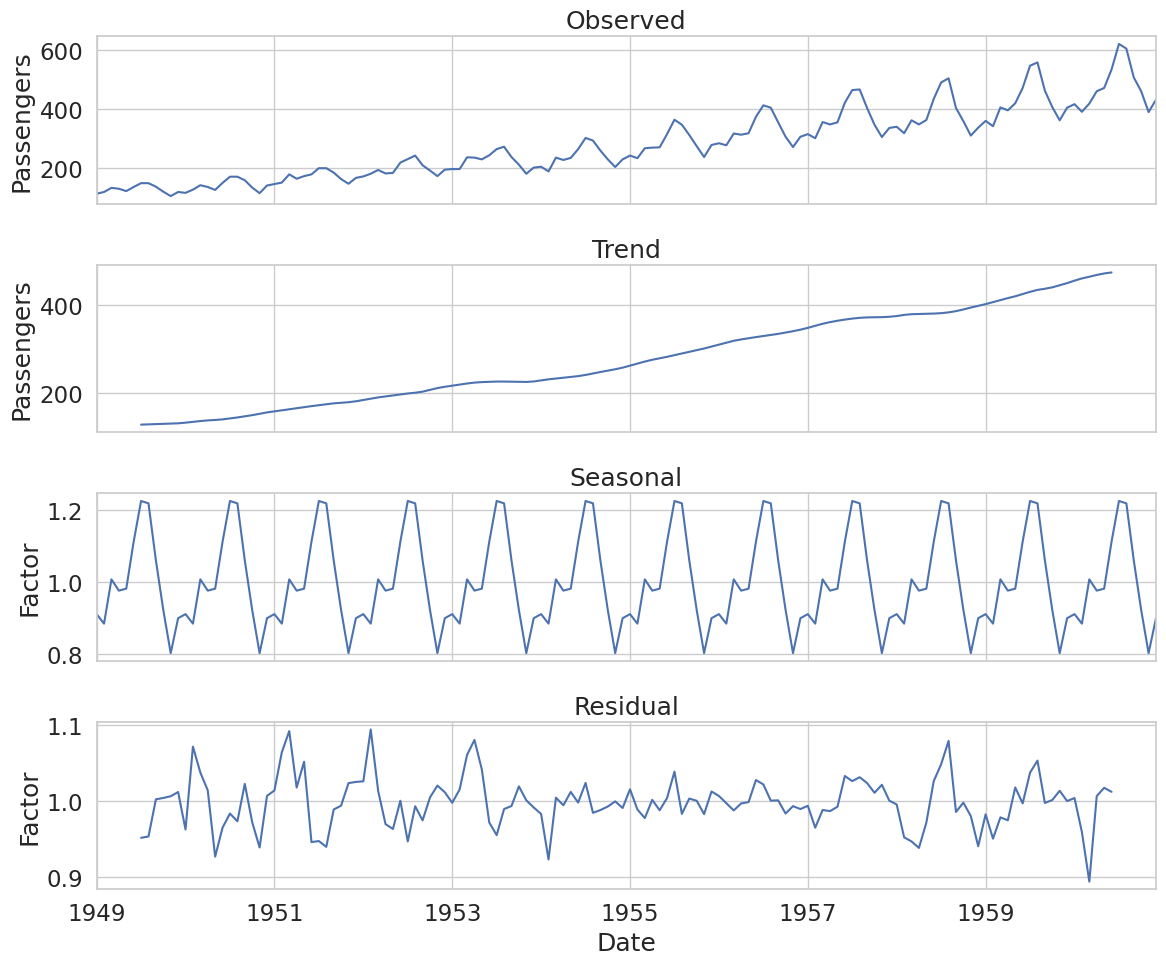

In [5]:
# Classical Decomposition using statsmodels
decomp = seasonal_decompose(passengers, period=12, model='multiplicative')

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed')
axes[0].set_ylabel('Passengers')
decomp.trend.plot(ax=axes[1], title='Trend')
axes[1].set_ylabel('Passengers')
decomp.seasonal.plot(ax=axes[2], title='Seasonal')
axes[2].set_ylabel('Factor')
decomp.resid.plot(ax=axes[3], title='Residual')
axes[3].set_ylabel('Factor')
axes[3].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 1.2 X-11 Decomposition

### Underlying Assumptions

X-11 improves on classical decomposition but still assumes:

1. **Slowly evolving seasonality** - Seasonal patterns can change but gradually
2. **Outliers are identifiable** - Extreme values can be detected and adjusted
3. **Local smoothness** - Henderson filter assumes local polynomial trend
4. **Multiplicative or additive structure** - Same structural assumption as classical

**Advantages over classical:**
- Better endpoint handling via asymmetric filters
- Robustness to outliers (using median in seasonal estimation)
- Iterative refinement improves estimates

**Key insight:** The Henderson filter provides smoother trend estimates than uniform MA by using polynomial-derived weights that better preserve turning points.

### Henderson Filter Weights

For a filter of length $m$ (must be odd), let $p = (m-1)/2$ and $n = p + 2$.

The Henderson weights for index $i \in \{-p, ..., p\}$ are:

$$w_i = \frac{315 \cdot [(n-1)^2 - i^2][n^2 - i^2][(n+1)^2 - i^2][3n^2 - 16 - 11i^2]}{8n(n^2-1)(4n^2-1)(4n^2-9)(4n^2-25)}$$

This is the JDemetra standard formulation, which produces symmetric weights summing to 1.

For the standard 13-term Henderson filter ($m=13$, $p=6$, $n=8$):
- Center weight $w_0 \approx 0.240$
- Edge weights $w_{\pm 6} \approx -0.019$ (slightly negative for smoothness)

### How Parameters Are Fit

**Iterative procedure (simplified):**

1. **Initial trend**: Centered MA (same as classical)
2. **For each iteration:**
   - Detrend: $SI_t = Y_t / T_t$ (seasonal-irregular)
   - Estimate seasonal: Median of $SI_t$ values for each period position
   - Normalize seasonal factors
   - Compute seasonally adjusted: $SA_t = Y_t / S_t$
   - Re-estimate trend with Henderson filter on $SA_t$
3. **Final residual**: $R_t = Y_t / (T_t \times S_t)$

**Why iterative?** Each pass refines both trend and seasonal estimates, reducing their mutual contamination.

In [6]:
def henderson_weights(filter_length):
    """Compute Henderson filter weights using JDemetra standard formula.

    Parameters
    ----------
    filter_length : int
        Filter length (must be odd)

    Returns
    -------
    weights : np.ndarray
    """
    if filter_length % 2 == 0:
        raise ValueError("filter_length must be odd")

    p = (filter_length - 1) // 2
    n = p + 2
    i = np.arange(-p, p + 1)

    # Henderson weight formula (JDemetra standard)
    num = 315 * ((n-1)**2 - i**2) * (n**2 - i**2) * ((n+1)**2 - i**2) * (3*n**2 - 16 - 11*i**2)
    denom = 8 * n * (n**2 - 1) * (4*n**2 - 1) * (4*n**2 - 9) * (4*n**2 - 25)

    weights = num / denom

    return weights


def apply_henderson_filter(y, h_weights):
    """Apply Henderson filter with proper edge handling.
    
    Uses 'valid' mode and fills edges with simple MA values.
    """
    n = len(y)
    pad = len(h_weights) // 2
    
    # Apply Henderson to core
    core = np.convolve(y, h_weights, mode='valid')
    
    # Build output array
    result = np.zeros(n)
    result[pad:pad + len(core)] = core
    
    # Handle edges with simple MA (gradually widening window)
    for i in range(pad):
        # Left edge: use available data
        left_window = y[:2*i + 1] if i > 0 else y[:1]
        result[i] = np.mean(left_window)
        
        # Right edge
        right_window = y[-(2*(pad-i) + 1):] if (pad-i) > 0 else y[-1:]
        result[-(i+1)] = np.mean(right_window)
    
    return result


def x11_decomposition(y, period=12, iterations=3):
    """Simplified X-11 seasonal decomposition.

    Parameters
    ----------
    y : pd.Series
        Time series
    period : int
        Seasonal period (default 12 for monthly)
    iterations : int
        Number of refinement iterations

    Returns
    -------
    dict with decomposition components
    """
    y_vals = np.asarray(y).astype(float)
    n = len(y_vals)

    # Henderson filter length (typically 13 for monthly data)
    h_len = 13 if period == 12 else min(2 * period + 1, 25)
    if h_len % 2 == 0:
        h_len += 1
    h_weights = henderson_weights(h_len)

    # Initial trend estimate using 2×period MA
    if period % 2 == 0:
        init_weights = np.ones(period + 1) / period
        init_weights[0] = 0.5 / period
        init_weights[-1] = 0.5 / period
    else:
        init_weights = np.ones(period) / period

    pad_init = len(init_weights) // 2
    trend_valid = np.convolve(y_vals, init_weights, mode='valid')
    trend = np.full(n, np.nan)
    trend[pad_init:pad_init + len(trend_valid)] = trend_valid
    
    # Fill edge NaNs
    trend[:pad_init] = trend[pad_init]
    trend[-(n - pad_init - len(trend_valid)):] = trend[pad_init + len(trend_valid) - 1]
    
    # Initial seasonal-irregular ratio
    si = y_vals / trend

    # Iterative refinement
    for _ in range(iterations):
        # Compute seasonal factors: median SI for each calendar month
        seasonal_factors = np.zeros(period)
        for m in range(period):
            month_vals = si[m::period]
            seasonal_factors[m] = np.nanmedian(month_vals)
        
        # Normalize factors to average to 1.0
        seasonal_factors = seasonal_factors / np.mean(seasonal_factors)
        
        # Tile seasonal factors to match data length
        n_complete = n // period
        seasonal = np.tile(seasonal_factors, n_complete + 1)[:n]

        # Seasonally adjusted series
        sa = y_vals / seasonal

        # Trend from Henderson filter
        trend = apply_henderson_filter(sa, h_weights)

        # Update SI for next iteration
        si = y_vals / trend

    # Final residual (irregular)
    residual = y_vals / (trend * seasonal)

    # Return as pandas Series with original index
    index = y.index if hasattr(y, 'index') else None
    return {
        'trend': pd.Series(trend, index=index),
        'seasonal': pd.Series(seasonal, index=index),
        'residual': pd.Series(residual, index=index),
        'seasonally_adjusted': pd.Series(sa, index=index)
    }

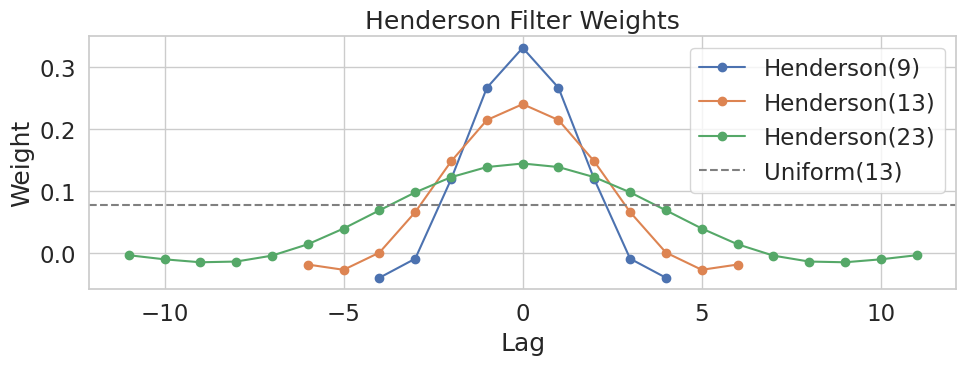

In [7]:
# Compare Henderson weights to uniform weights
fig, ax = plt.subplots(figsize=(10, 4))

for n in [9, 13, 23]:
    w = henderson_weights(n)
    ax.plot(np.arange(-(n-1)//2, (n-1)//2 + 1), w, 'o-', label=f'Henderson({n})')

# Uniform weights for comparison
n = 13
ax.axhline(1/n, color='gray', linestyle='--', label=f'Uniform({n})')

ax.set_xlabel('Lag')
ax.set_ylabel('Weight')
ax.set_title('Henderson Filter Weights')
ax.legend()
plt.tight_layout()
plt.show()

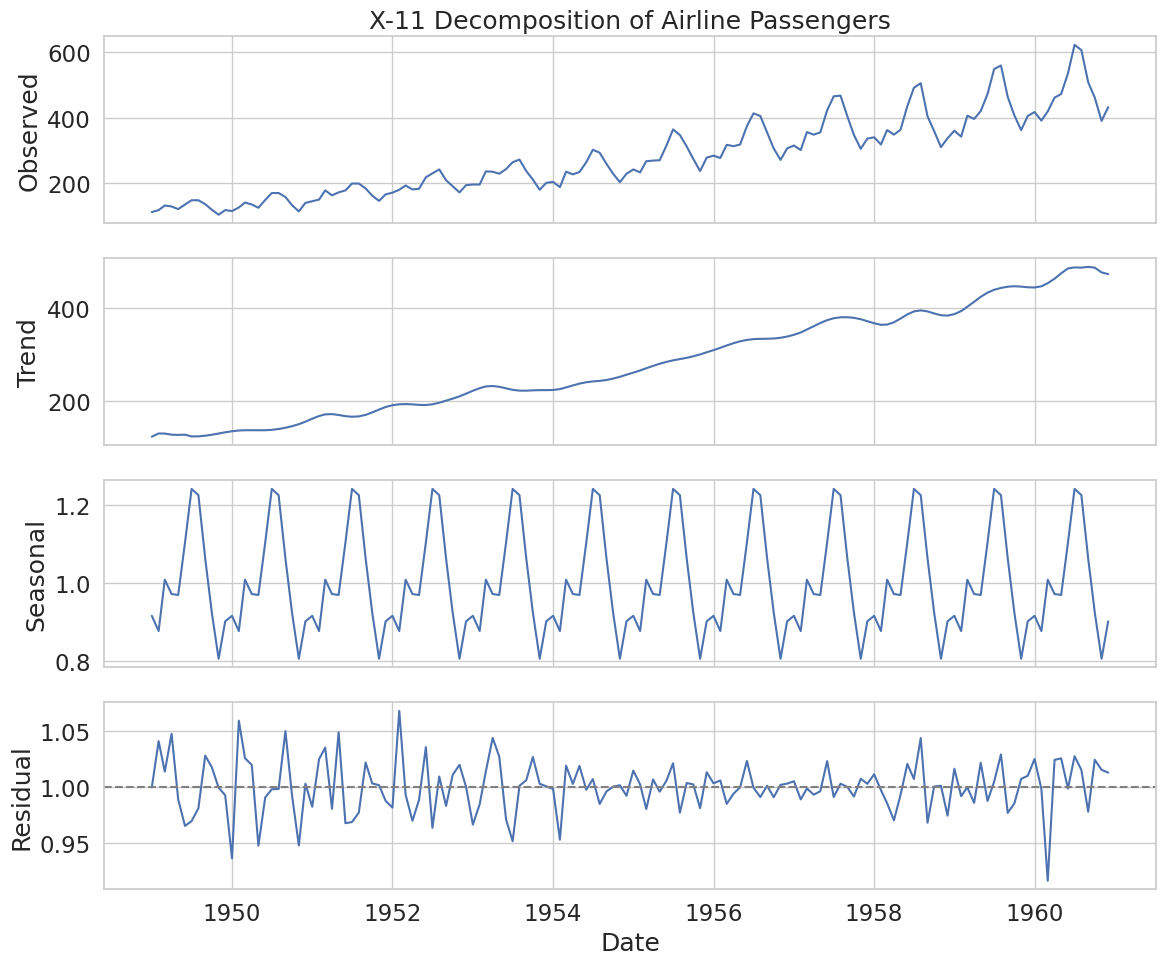

In [8]:
# Apply X-11 decomposition
x11_decomp = x11_decomposition(passengers, period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

idx = passengers.index

axes[0].plot(idx, passengers)
axes[0].set_ylabel('Observed')
axes[0].set_title('X-11 Decomposition of Airline Passengers')

axes[1].plot(idx, x11_decomp['trend'])
axes[1].set_ylabel('Trend')

axes[2].plot(idx, x11_decomp['seasonal'])
axes[2].set_ylabel('Seasonal')

axes[3].plot(idx, x11_decomp['residual'])
axes[3].axhline(1, color='gray', linestyle='--')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.show()

## 1.3 STL Decomposition (LOESS-based)

### Underlying Assumptions

**STL** (Seasonal and Trend decomposition using LOESS) assumes:

1. **Local smoothness** - Trend and seasonal components vary smoothly (can be captured by local polynomial)
2. **Additive structure** - STL is inherently additive ($Y_t = T_t + S_t + R_t$)
3. **Seasonal component varies slowly** - Seasonality can evolve but not too rapidly
4. **Outliers are minority** - Robust version downweights outliers assuming they're rare

**When to use:**
- Series with evolving seasonal patterns
- Data with potential outliers (use robust version)
- When you need separate control of trend and seasonal smoothing
- When interpretability matters (clear decomposition)

**When NOT to use:**
- Multiplicative seasonality (transform first with log)
- Very short series (LOESS needs sufficient local data)
- Multiple seasonal periods (use MSTL instead)

### Key Features

1. **LOESS for trend** - Local polynomial regression with tricube weights
2. **Robustness** - Iteratively reweighted least squares (IRLS) for outlier resistance
3. **Flexibility** - Separate control over trend and seasonal smoothness

### LOESS Algorithm

For each point $x_i$:

1. **Find neighbors**: Select $k = \text{frac} \times n$ nearest points
2. **Compute weights**: $w_j = W\left(\frac{|x_j - x_i|}{h_i}\right)$ where $h_i$ is bandwidth
3. **Weighted least squares**: Fit polynomial $\hat{y} = \beta_0 + \beta_1(x - x_i) + ...$
4. **Predict**: $\hat{y}_i = \beta_0$

### Tricube Weight Function

$$W(u) = (1 - |u|^3)^3 \cdot \mathbf{1}_{|u| < 1}$$

This gives smooth, zero-at-boundary weights that ensure local influence.

### How Parameters Are Fit

**Inner loop (trend/seasonal extraction):**
1. Detrend by subtracting current trend estimate
2. Apply LOESS to each seasonal subseries (e.g., all Januaries)
3. Subtract low-pass filter of seasonal to ensure it sums to ~zero
4. Deseasonalize and apply LOESS to get new trend

**Outer loop (robustness):**
1. Compute residuals
2. Calculate robustness weights based on residual size
3. Re-run inner loop with robustness-weighted LOESS

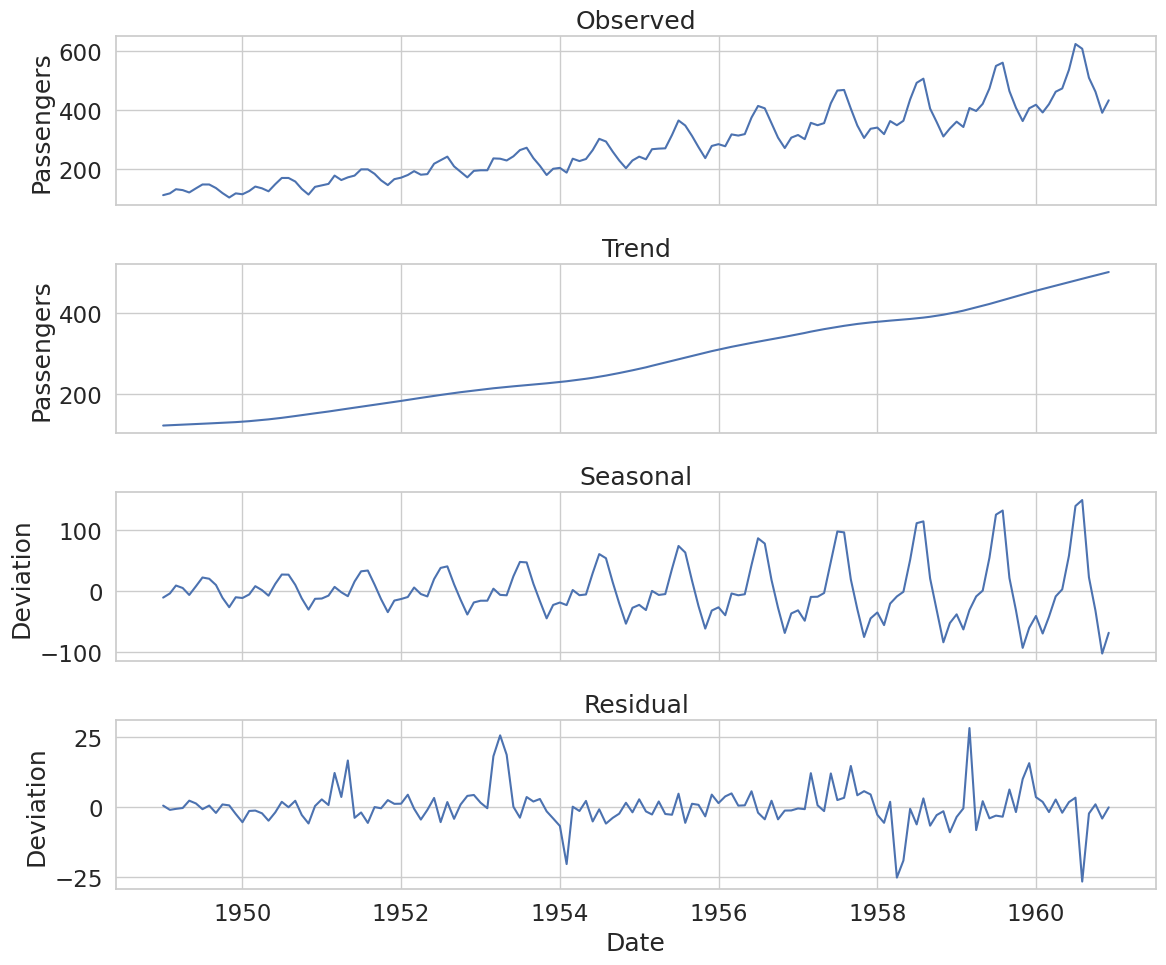

In [9]:
# STL Decomposition using statsmodels
stl = STL(passengers, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(passengers)
axes[0].set_title('Observed')
axes[0].set_ylabel('Passengers')
axes[1].plot(stl.trend)
axes[1].set_title('Trend')
axes[1].set_ylabel('Passengers')
axes[2].plot(stl.seasonal)
axes[2].set_title('Seasonal')
axes[2].set_ylabel('Deviation')
axes[3].plot(stl.resid)
axes[3].set_title('Residual')
axes[3].set_ylabel('Deviation')
axes[3].set_xlabel('Date')
plt.tight_layout()
plt.show()

### Comparison: Classical vs X-11 vs STL

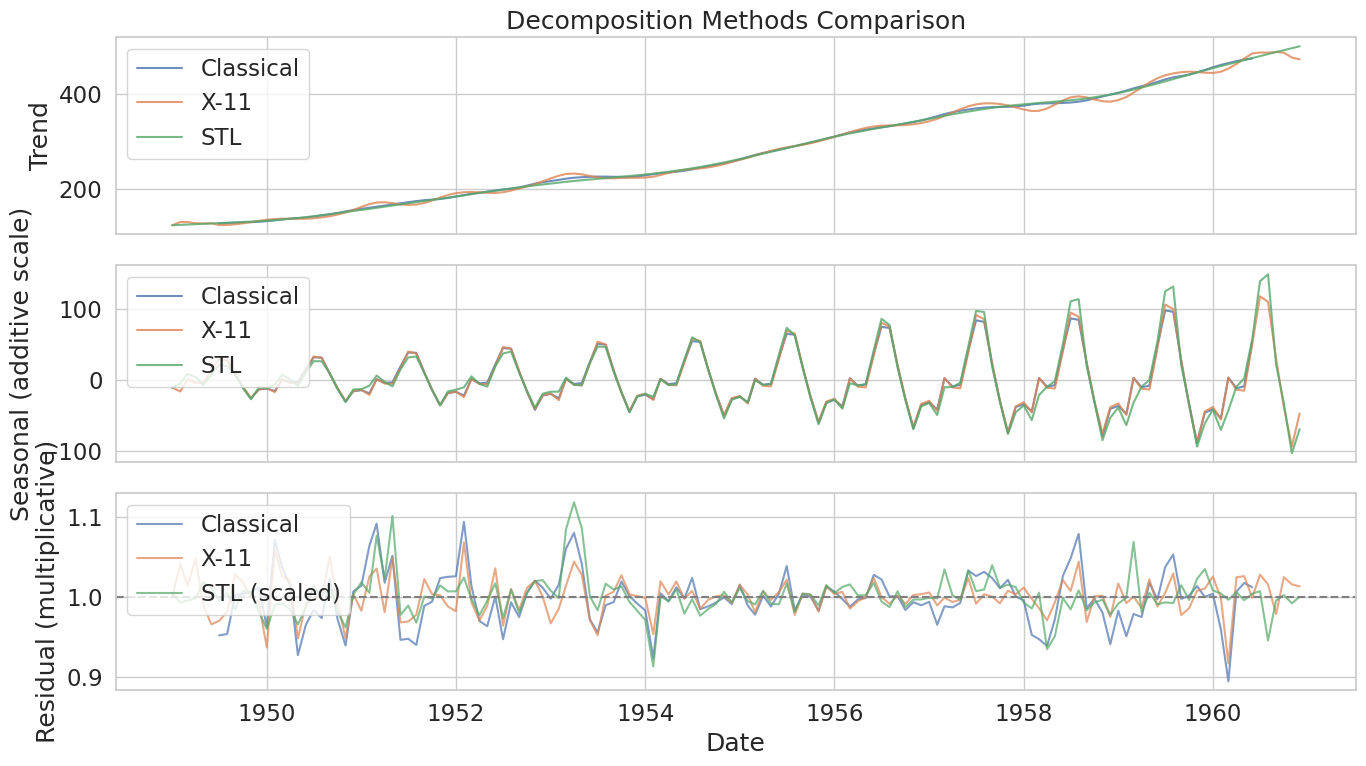

Residual Standard Deviations:
  Classical: 0.0333
  X-11:      0.0232
  STL:       0.0257


In [23]:
# Compare all three methods
classical = seasonal_decompose(passengers, period=12, model='multiplicative')
x11 = x11_decomposition(passengers, period=12)
stl = STL(passengers, period=12, robust=True).fit()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

idx = passengers.index

# Trend comparison
axes[0].plot(idx, classical.trend, label='Classical', alpha=0.8)
axes[0].plot(idx, x11['trend'], label='X-11', alpha=0.8)
axes[0].plot(idx, stl.trend, label='STL', alpha=0.8)
axes[0].set_ylabel('Trend')
axes[0].legend(loc='upper left')
axes[0].set_title('Decomposition Methods Comparison')

# Seasonal comparison - convert multiplicative to additive scale: (S-1)*T
# This makes all methods comparable in original units
classical_seasonal_additive = (classical.seasonal - 1) * classical.trend
x11_seasonal_additive = (x11['seasonal'] - 1) * x11['trend']

axes[1].plot(idx, classical_seasonal_additive, label='Classical', alpha=0.8)
axes[1].plot(idx, x11_seasonal_additive, label='X-11', alpha=0.8)
axes[1].plot(idx, stl.seasonal, label='STL', alpha=0.8)
axes[1].set_ylabel('Seasonal (additive scale)')
axes[1].legend(loc='upper left')

# Residual comparison - convert additive to multiplicative scale
axes[2].plot(idx, classical.resid, label='Classical', alpha=0.7)
axes[2].plot(idx, x11['residual'], label='X-11', alpha=0.7)
# STL is additive; convert to multiplicative: resid/trend + 1
axes[2].plot(idx, stl.resid / stl.trend + 1, label='STL (scaled)', alpha=0.7)
axes[2].axhline(1, color='gray', linestyle='--')
axes[2].set_ylabel('Residual (multiplicative)')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

# Residual statistics
print("Residual Standard Deviations:")
print(f"  Classical: {np.nanstd(classical.resid):.4f}")
print(f"  X-11:      {np.nanstd(x11['residual']):.4f}")
print(f"  STL:       {np.nanstd(stl.resid / stl.trend + 1):.4f}")

---

# Part 2: ARMA/ARIMA Modeling

Building on Tutorial 3, we explore automatic model selection and advanced forecasting methods.

## 2.1 ARMA Fitting Recap

### Underlying Assumptions

ARMA(p,q) models assume:

1. **Weak stationarity** - Constant mean, variance, and autocovariance structure
   - $E[X_t] = \mu$ (constant mean)
   - $Var(X_t) = \sigma^2$ (constant variance)
   - $Cov(X_t, X_{t+h})$ depends only on lag $h$

2. **Linear dependence** - Current value is a linear combination of past values and errors

3. **White noise innovations** - $\varepsilon_t \sim WN(0, \sigma^2)$
   - Uncorrelated (not necessarily independent)
   - Constant variance

4. **Invertibility (MA)** - MA polynomial roots outside unit circle
   - Ensures unique representation

5. **Causality (AR)** - AR polynomial roots outside unit circle
   - Ensures process depends only on past

**When to use:**
- Stationary or differenced-to-stationary series
- Short-term forecasting
- Series with clear autocorrelation structure

**When NOT to use:**
- Non-stationary series (use ARIMA)
- Series with volatility clustering (use GARCH)
- Long-memory processes (use ARFIMA)
- Series with structural breaks

### AR(p) Model

$$\phi(B)X_t = \varepsilon_t$$

where $\phi(B) = 1 - \phi_1 B - \phi_2 B^2 - \cdots - \phi_p B^p$ and $B$ is the backshift operator.

Equivalently: $X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \cdots + \phi_p X_{t-p} + \varepsilon_t$

### MA(q) Model

$$X_t = \theta(B)\varepsilon_t$$

where $\theta(B) = 1 + \theta_1 B + \theta_2 B^2 + \cdots + \theta_q B^q$

### ARMA(p,q) Model

$$\phi(B)X_t = \theta(B)\varepsilon_t$$

### How Parameters Are Fit

**Method: Maximum Likelihood Estimation (MLE)**

The likelihood function for Gaussian ARMA:
$$L(\phi, \theta, \sigma^2 | X) = \prod_{t=1}^{n} f(X_t | X_{t-1}, ..., X_1)$$

**In practice:**
1. **Initialize** using method of moments or CSS (Conditional Sum of Squares)
2. **Optimize** using Kalman filter to compute likelihood efficiently
3. **Select order** using information criteria

### Model Selection: AIC and BIC

$$\text{AIC} = -2\log L + 2k$$
$$\text{BIC} = -2\log L + k\log n$$

where $k$ is the number of parameters and $n$ is the sample size.

**AIC** prefers more complex models (good for prediction)
**BIC** penalizes complexity more (consistent for model selection)

## 2.2 PMD ARIMA (Auto ARIMA)

The `pmdarima` package provides automatic ARIMA order selection using:

1. **Stepwise search** - Starts from a baseline and iteratively improves
2. **Exhaustive search** - Tests all combinations (slower but thorough)

### Seasonal ARIMA: SARIMA(p,d,q)(P,D,Q)_m

$$\Phi_P(B^m)\phi(B)(1-B^m)^D(1-B)^d X_t = \Theta_Q(B^m)\theta(B)\varepsilon_t$$

where:
- $(p, d, q)$ = non-seasonal orders
- $(P, D, Q)$ = seasonal orders
- $m$ = seasonal period

In [11]:
# Prepare stationary data (differenced log passengers)
y_diff = log_passengers.diff().dropna()

# Auto ARIMA with stepwise search
auto_model = pm.auto_arima(
    log_passengers,
    seasonal=True,
    m=12,  # Monthly seasonality
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None,  # Auto-detect differencing
    D=None,  # Auto-detect seasonal differencing
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\n" + "="*50)
print("Best Model Summary:")
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-358.005, Time=0.12 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-472.836, Time=0.38 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-423.080, Time=0.43 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-152.756, Time=0.01 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=-452.647, Time=0.15 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=-476.268, Time=5.74 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=-476.226, Time=3.70 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=-476.099, Time=0.48 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=-363.693, Time=3.87 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=-484.494, Time=5.33 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=-482.539, Time=0.49 sec
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=-482.993, Time=4.45 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=-486.922, Time=0.43 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=-489.295, Time=0.29 sec
 ARIMA(2,0,0)(0,1,0

## 2.3 Three Forecasting Methods for AR Models

Given a fitted AR(p) model: $X_t = \phi_1 X_{t-1} + \cdots + \phi_p X_{t-p} + \varepsilon_t$

### Method 1: Fixed-Coefficient Decay (Recursive Forecasting)

**Assumptions:**
- Model parameters remain constant over forecast horizon
- No new information becomes available
- Best linear predictor given current information

For horizon $h > 0$:
$$\hat{X}_{t+h} = \sum_{i=1}^{p} \phi_i \hat{X}_{t+h-i}$$

where $\hat{X}_{t+j} = X_{t+j}$ for $j \leq 0$ (use actual values for the past).

**Behavior**: Forecasts converge to the unconditional mean as $h \to \infty$ (geometric decay).

**When to use**: Long-horizon forecasts, scenario analysis, no future data expected.

### Method 2: Dynamic Forecasting with Observed Data

**Assumptions:**
- Parameters are correct but we update information as it arrives
- One-step-ahead forecasts using latest actual observations

As new observations become available, update forecasts:
$$\hat{X}_{t+h|t+h-1} = \sum_{i=1}^{p} \phi_i Y_{t+h-i}$$

where $Y_{t+h-i}$ is the **actual observed value** (not the forecast).

**When to use**: Rolling one-step-ahead evaluation, model validation.

### Method 3: Rolling/Expanding Window Refit

**Assumptions:**
- Model parameters may drift over time
- Refitting captures parameter evolution
- Computational cost is acceptable

Periodically refit the model as new data arrives:

- **Rolling window**: Refit on $[t+h-w, t+h-1]$ with fixed window size $w$
- **Expanding window**: Refit on $[1, t+h-1]$ with growing data

**When to use**:
- Rolling: Suspected parameter drift, want recent data emphasis
- Expanding: Stable parameters, want all available information

In [12]:
def ar_forecast_fixed_coef(y, phi, horizon, mean=0):
    """Method 1: Fixed-coefficient recursive forecasting.
    
    Parameters
    ----------
    y : array-like
        Historical values (most recent at end)
    phi : array-like
        AR coefficients [phi_1, phi_2, ..., phi_p]
    horizon : int
        Number of steps ahead to forecast
    mean : float
        Unconditional mean of the process
    
    Returns
    -------
    forecasts : np.ndarray of length horizon
    """
    y = np.asarray(y) - mean
    phi = np.asarray(phi)
    p = len(phi)
    
    # Buffer for forecasts (include last p values from history)
    buffer = np.zeros(p + horizon)
    buffer[:p] = y[-p:]
    
    # Recursive forecasting
    for h in range(horizon):
        buffer[p + h] = np.dot(phi, buffer[p + h - 1::-1][:p])
    
    return buffer[p:] + mean


def ar_forecast_dynamic(y_train, y_test, phi, mean=0):
    """Method 2: Dynamic forecasting using actual observations.
    
    Parameters
    ----------
    y_train : array-like
        Training data
    y_test : array-like
        Test data (actual values revealed one at a time)
    phi : array-like
        AR coefficients
    mean : float
        Unconditional mean
    
    Returns
    -------
    forecasts : np.ndarray (one-step-ahead forecasts)
    """
    y_train = np.asarray(y_train) - mean
    y_test = np.asarray(y_test) - mean
    phi = np.asarray(phi)
    p = len(phi)
    
    all_data = np.concatenate([y_train, y_test])
    n_train = len(y_train)
    n_test = len(y_test)
    
    forecasts = np.zeros(n_test)
    
    for t in range(n_test):
        # Use actual values up to current time
        idx = n_train + t
        # Reverse slice to get [X_{t-1}, X_{t-2}, ..., X_{t-p}] for dot product with [φ₁, φ₂, ..., φ_p]
        forecasts[t] = np.dot(phi, all_data[idx - 1::-1][:p])
    
    return forecasts + mean


def ar_forecast_rolling(y, order=2, train_size=None, window_type='expanding'):
    """Method 3: Rolling/expanding window refit.
    
    Parameters
    ----------
    y : pd.Series
        Full time series
    order : int
        AR order
    train_size : int
        Initial training size
    window_type : str
        'rolling' or 'expanding'
    
    Returns
    -------
    forecasts : np.ndarray
    actuals : np.ndarray
    """
    y = np.asarray(y)
    n = len(y)
    
    if train_size is None:
        train_size = n // 2
    
    forecasts = []
    actuals = []
    
    for t in range(train_size, n):
        if window_type == 'rolling':
            # Fixed window size
            window_start = max(0, t - train_size)
            y_window = y[window_start:t]
        else:  # expanding
            y_window = y[:t]
        
        # Fit AR model
        try:
            model = ARIMA(y_window, order=(order, 0, 0))
            fit = model.fit()
            # One-step forecast
            fc = fit.forecast(1)[0]
        except:
            fc = np.mean(y_window)
        
        forecasts.append(fc)
        actuals.append(y[t])
    
    return np.array(forecasts), np.array(actuals)

Fitted AR(2) coefficients: phi_1=0.1973, phi_2=-0.1832


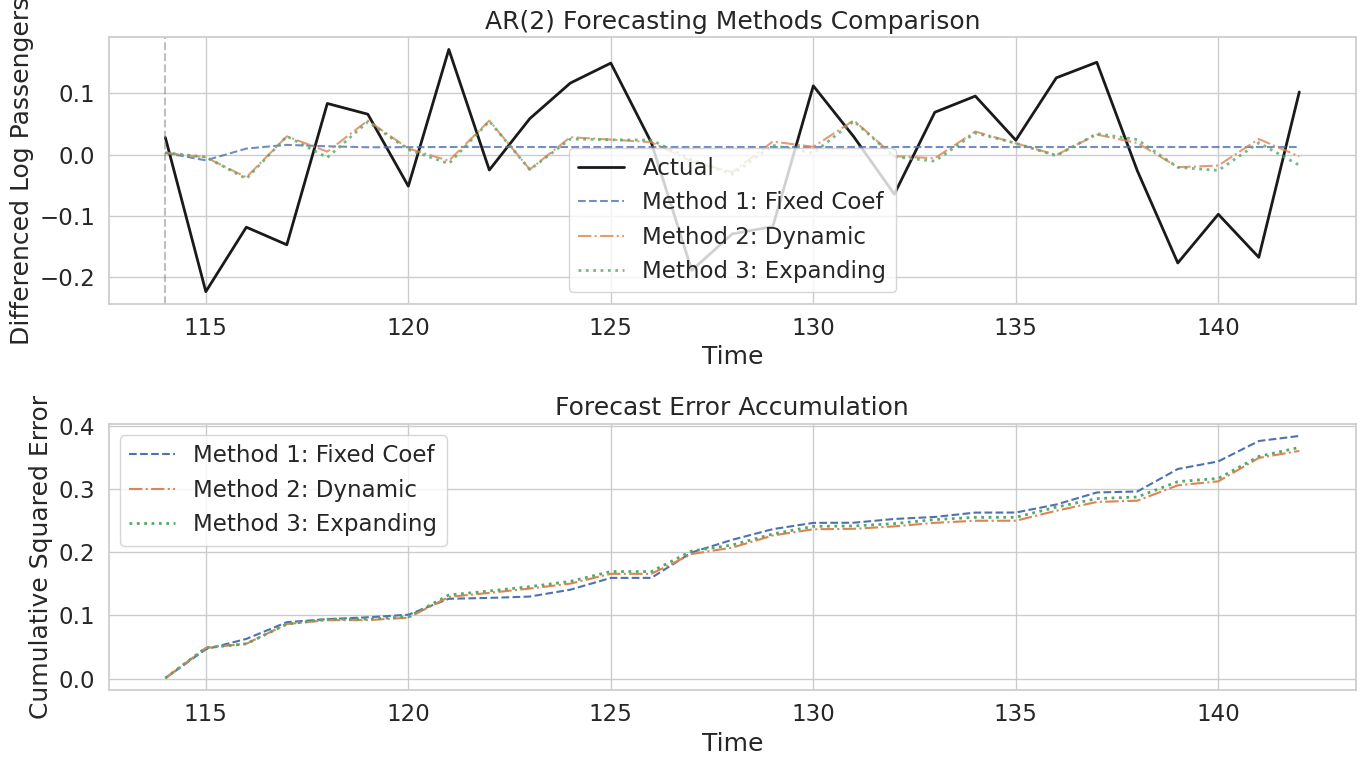


RMSE Comparison:
  Method 1 (Fixed Coef):  0.1151
  Method 2 (Dynamic):     0.1115
  Method 3 (Expanding):   0.1124


In [13]:
# Demonstrate the three forecasting methods on differenced log passengers
y = y_diff.values
n = len(y)
train_size = int(0.8 * n)

y_train = y[:train_size]
y_test = y[train_size:]

# Fit AR(2) model on training data
ar_model = ARIMA(y_train, order=(2, 0, 0)).fit()
phi = ar_model.arparams
mu = ar_model.params[0] if 'const' in ar_model.param_names else 0

print(f"Fitted AR(2) coefficients: phi_1={phi[0]:.4f}, phi_2={phi[1]:.4f}")

# Method 1: Fixed-coefficient forecasting
fc_fixed = ar_forecast_fixed_coef(y_train, phi, len(y_test), mean=mu)

# Method 2: Dynamic forecasting
fc_dynamic = ar_forecast_dynamic(y_train, y_test, phi, mean=mu)

# Method 3: Expanding window refit
fc_expanding, actuals = ar_forecast_rolling(
    y, order=2, train_size=train_size, window_type='expanding'
)

# Compare methods
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: Forecasts vs actual
time_idx = np.arange(train_size, n)
axes[0].plot(time_idx, y_test, 'k-', label='Actual', linewidth=2)
axes[0].plot(time_idx, fc_fixed, '--', label='Method 1: Fixed Coef', alpha=0.8)
axes[0].plot(time_idx, fc_dynamic, '-.', label='Method 2: Dynamic', alpha=0.8)
axes[0].plot(time_idx, fc_expanding, ':', label='Method 3: Expanding', alpha=0.8, linewidth=2)
axes[0].axvline(train_size, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Differenced Log Passengers')
axes[0].set_title('AR(2) Forecasting Methods Comparison')
axes[0].legend()

# Bottom: Cumulative squared errors
cse_fixed = np.cumsum((y_test - fc_fixed)**2)
cse_dynamic = np.cumsum((y_test - fc_dynamic)**2)
cse_expanding = np.cumsum((y_test - fc_expanding)**2)

axes[1].plot(time_idx, cse_fixed, '--', label='Method 1: Fixed Coef')
axes[1].plot(time_idx, cse_dynamic, '-.', label='Method 2: Dynamic')
axes[1].plot(time_idx, cse_expanding, ':', label='Method 3: Expanding', linewidth=2)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Cumulative Squared Error')
axes[1].set_title('Forecast Error Accumulation')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print RMSE comparison
print("\nRMSE Comparison:")
print(f"  Method 1 (Fixed Coef):  {np.sqrt(np.mean((y_test - fc_fixed)**2)):.4f}")
print(f"  Method 2 (Dynamic):     {np.sqrt(np.mean((y_test - fc_dynamic)**2)):.4f}")
print(f"  Method 3 (Expanding):   {np.sqrt(np.mean((y_test - fc_expanding)**2)):.4f}")

---

# Part 3: GARCH Models

Generalized Autoregressive Conditional Heteroskedasticity models for volatility modeling.

## 3.1 Motivation: Volatility Clustering

### Stylized Facts of Financial Returns

1. **Heavy tails** - Returns have fatter tails than normal distribution
2. **Volatility clustering** - Large changes tend to be followed by large changes
3. **Leverage effect** - Negative returns often increase volatility more than positive returns
4. **Mean reversion of volatility** - Volatility tends to revert to a long-run mean

### ARCH Effects

The ARCH-LM test (Engle, 1982) detects autoregressive conditional heteroskedasticity:

$$H_0: \alpha_1 = \alpha_2 = \cdots = \alpha_q = 0$$

in the regression:
$$\varepsilon_t^2 = \alpha_0 + \alpha_1 \varepsilon_{t-1}^2 + \cdots + \alpha_q \varepsilon_{t-q}^2 + v_t$$

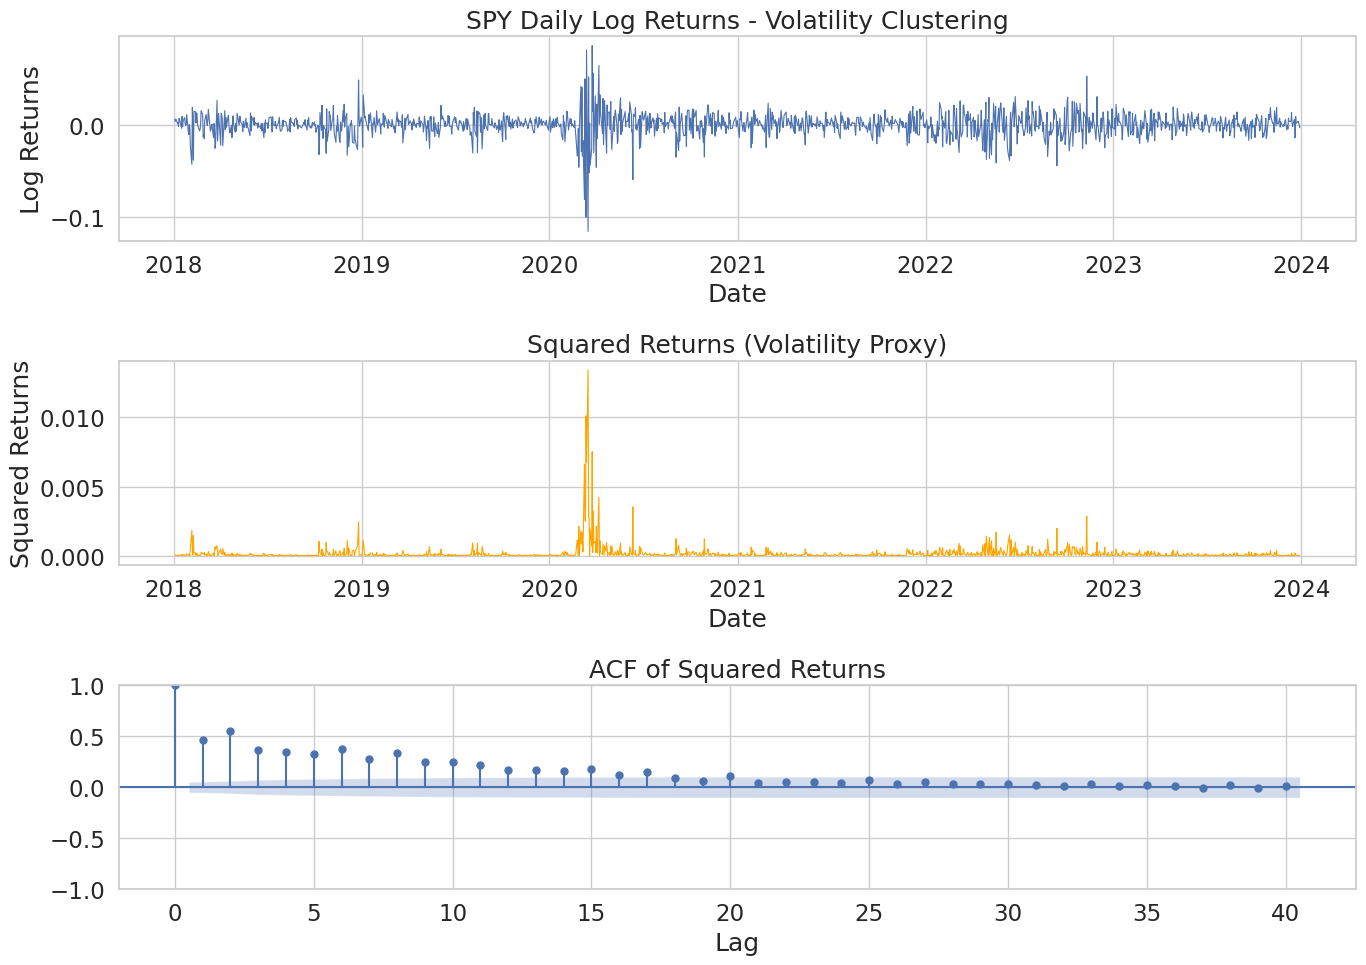


ARCH-LM Test (10 lags):
  LM Statistic: 582.34
  P-value: 1.0676e-118
  Conclusion: ARCH effects present


In [14]:
# Demonstrate volatility clustering in stock returns
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Returns
axes[0].plot(spy_returns, linewidth=0.8)
axes[0].set_ylabel('Log Returns')
axes[0].set_title('SPY Daily Log Returns - Volatility Clustering')
axes[0].set_xlabel('Date')

# Squared returns (proxy for volatility)
axes[1].plot(spy_returns**2, linewidth=0.8, color='orange')
axes[1].set_ylabel('Squared Returns')
axes[1].set_title('Squared Returns (Volatility Proxy)')
axes[1].set_xlabel('Date')

# ACF of squared returns
plot_acf(spy_returns**2, lags=40, ax=axes[2], alpha=0.05)
axes[2].set_title('ACF of Squared Returns')
axes[2].set_xlabel('Lag')

plt.tight_layout()
plt.show()

# ARCH-LM test
arch_test = het_arch(spy_returns.dropna(), nlags=10)
print(f"\nARCH-LM Test (10 lags):")
print(f"  LM Statistic: {arch_test[0]:.2f}")
print(f"  P-value: {arch_test[1]:.4e}")
conclusion = 'ARCH effects present' if arch_test[1] < 0.05 else 'No significant ARCH effects'
print(f"  Conclusion: {conclusion}")

## 3.2 GARCH(p,q) Model

### Underlying Assumptions

GARCH models assume:

1. **Conditional heteroskedasticity** - Variance changes over time but is predictable from past
   - Unconditional variance is constant (stationarity)
   - Conditional variance $\sigma_t^2$ depends on past squared returns and variances

2. **Martingale difference** - Returns are unpredictable in mean
   - $E[r_t | \mathcal{F}_{t-1}] = \mu$
   - Predictability is in variance, not level

3. **Symmetric response** - Positive and negative shocks affect volatility equally
   - Violated in practice (leverage effect)
   - Extensions: EGARCH, GJR-GARCH handle asymmetry

4. **No serial correlation in returns** - After removing mean, residuals are uncorrelated
   - But squared residuals are correlated (that's what GARCH captures)

5. **Innovation distribution** - Usually Gaussian, but can use Student-t or GED
   - Heavy tails in returns suggest non-Gaussian innovations

**When to use:**
- Financial return series with volatility clustering
- Risk management (VaR, expected shortfall)
- Option pricing (stochastic volatility proxy)
- Volatility forecasting

**When NOT to use:**
- Non-financial series without heteroskedasticity
- Series with level predictability (use ARMA-GARCH)
- Asymmetric volatility response (use EGARCH/GJR)

### Model Specification

$$r_t = \mu + \varepsilon_t$$
$$\varepsilon_t = \sigma_t z_t, \quad z_t \sim N(0,1)$$
$$\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2$$

### Parameter Constraints

- $\omega > 0$ (positive intercept)
- $\alpha_i \geq 0$, $\beta_j \geq 0$ (non-negative coefficients)
- $\sum_{i=1}^{q} \alpha_i + \sum_{j=1}^{p} \beta_j < 1$ (stationarity)

### Unconditional Variance

$$\text{Var}(\varepsilon_t) = \frac{\omega}{1 - \sum \alpha_i - \sum \beta_j}$$

### Persistence

The **persistence** $\sum \alpha_i + \sum \beta_j$ measures how quickly volatility shocks decay.
- Values close to 1: Highly persistent (volatility shocks take long to die out)
- Values close to 0: Rapid mean reversion

### How Parameters Are Fit

**Method: Gaussian Quasi-Maximum Likelihood (QMLE)**

Log-likelihood (assuming Gaussian innovations):
$$\ell(\theta) = -\frac{1}{2} \sum_{t=1}^{n} \left[ \log(2\pi) + \log(\sigma_t^2) + \frac{\varepsilon_t^2}{\sigma_t^2} \right]$$

**Algorithm:**
1. Initialize $\sigma_1^2$ with unconditional variance estimate
2. Recursively compute $\sigma_t^2$ for $t = 2, ..., n$
3. Evaluate log-likelihood
4. Optimize using constrained numerical methods (ensure positivity and stationarity)

**Note:** QMLE is consistent even if true innovations are non-Gaussian, but standard errors need adjustment.

## 3.3 Implementation

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2141.42
Distribution:                  Normal   AIC:                           4290.85
Method:            Maximum Likelihood   BIC:                           4312.12
                                        No. Observations:                 1508
Date:                Mon, Jan 19 2026   Df Residuals:                     1507
Time:                        18:45:58   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1000  2.181e-02      4.584  4.553e-06 [5.723e-0

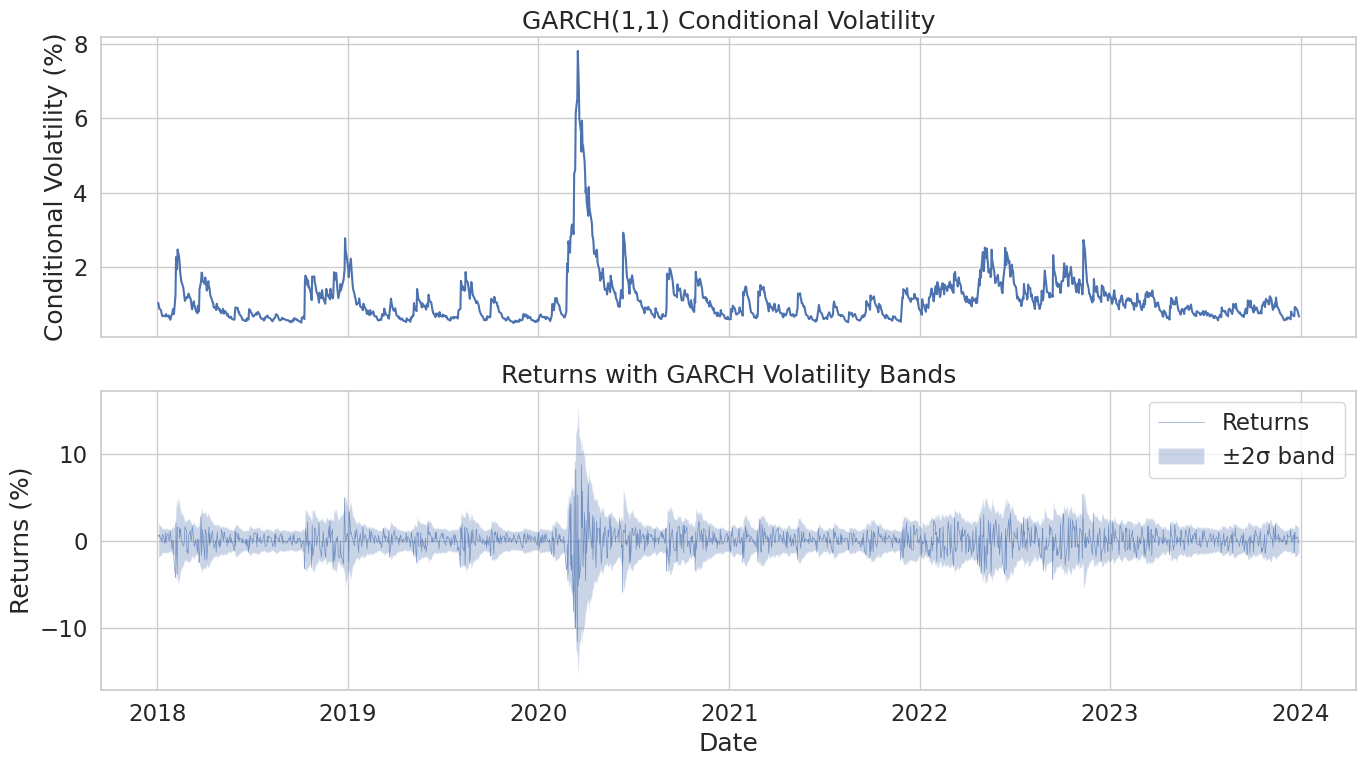


GARCH(1,1) Parameters:
  omega:       0.048619
  alpha[1]:    0.2054
  beta[1]:     0.7713
  Persistence: 0.9767


In [15]:
# Fit GARCH(1,1) using arch package
returns = spy_returns.dropna().values * 100  # Convert to percentage for numerical stability
am = arch_model(returns, vol='Garch', p=1, q=1, mean='Constant')
garch_fit = am.fit(disp='off')

print(garch_fit.summary())

# Plot conditional volatility
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Conditional volatility
axes[0].plot(spy_returns.index, garch_fit.conditional_volatility)
axes[0].set_ylabel('Conditional Volatility (%)')
axes[0].set_title('GARCH(1,1) Conditional Volatility')

# Returns with volatility bands
returns_pct = returns
axes[1].plot(spy_returns.index, returns_pct, linewidth=0.5, alpha=0.7, label='Returns')
axes[1].fill_between(spy_returns.index,
                     -2*garch_fit.conditional_volatility,
                     2*garch_fit.conditional_volatility,
                     alpha=0.3, label='±2σ band')
axes[1].set_ylabel('Returns (%)')
axes[1].set_xlabel('Date')
axes[1].set_title('Returns with GARCH Volatility Bands')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print key parameters
print(f"\nGARCH(1,1) Parameters:")
print(f"  omega:       {garch_fit.params['omega']:.6f}")
print(f"  alpha[1]:    {garch_fit.params['alpha[1]']:.4f}")
print(f"  beta[1]:     {garch_fit.params['beta[1]']:.4f}")
print(f"  Persistence: {garch_fit.params['alpha[1]'] + garch_fit.params['beta[1]']:.4f}")

# Check for high persistence (approaching IGARCH)
persistence = garch_fit.params['alpha[1]'] + garch_fit.params['beta[1]']
if persistence >= 0.99:
    print(f"Warning: High persistence ({persistence:.4f}) - model approaches IGARCH")

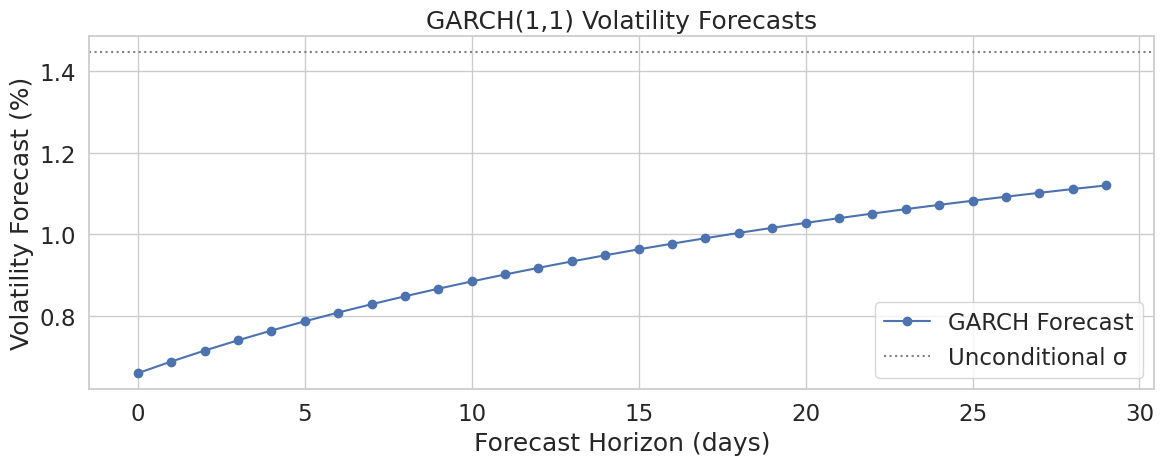

In [16]:
# Volatility forecasting using arch package
forecast = garch_fit.forecast(horizon=30)
fc_variance = forecast.variance.iloc[-1].values

# Compute unconditional variance for reference
omega = garch_fit.params['omega']
alpha = garch_fit.params['alpha[1]']
beta = garch_fit.params['beta[1]']
uncond_var = omega / (1 - alpha - beta)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(np.sqrt(fc_variance), 'o-', label='GARCH Forecast')
ax.axhline(np.sqrt(uncond_var), color='gray', linestyle=':', label='Unconditional σ')
ax.set_xlabel('Forecast Horizon (days)')
ax.set_ylabel('Volatility Forecast (%)')
ax.set_title('GARCH(1,1) Volatility Forecasts')
ax.legend()
plt.tight_layout()
plt.show()

---

# Part 4: Modern Techniques

State-of-the-art methods from 2024-2025 research and industry.

## 4.1 Prophet-Style Decomposition

### Underlying Assumptions

Prophet assumes:

1. **Piecewise linear (or logistic) trend** - Trend can have changepoints but is linear between them
   - Changepoints are either specified or automatically detected
   - Rate changes are regularized to prevent overfitting

2. **Fourier seasonality** - Seasonal patterns can be captured by Fourier series
   - Assumption: seasonality is smooth and periodic
   - Multiple seasonalities (yearly, weekly, daily) are additive

3. **Sparse changepoints** - Most time points don't have trend changes
   - Regularization (Laplace prior) encourages sparsity
   - User controls flexibility via changepoint_prior_scale

4. **Additive structure** - Components combine additively (or multiplicatively with log transform)
   - $y(t) = g(t) + s(t) + h(t) + \varepsilon_t$

5. **Smooth evolution** - No sudden jumps except at changepoints

**When to use:**
- Business time series with clear seasonality
- Data with known holidays/events
- When interpretable components are needed
- Quick baseline forecasting

**When NOT to use:**
- High-frequency data (sub-daily without modification)
- Series with complex non-linear patterns
- When you need confidence intervals accounting for parameter uncertainty

### Mathematical Formulation

Facebook's **Prophet** (Taylor & Letham, 2018) is an additive regression model:

$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$

where:
- $g(t)$ = **Trend** (piecewise linear or logistic growth)
- $s(t)$ = **Seasonality** (Fourier series)
- $h(t)$ = **Holiday effects**
- $\varepsilon_t$ = **Error**

### Trend Component

**Piecewise linear trend** with changepoints $\{s_j\}_{j=1}^S$:

$$g(t) = (k + \mathbf{a}(t)^T \boldsymbol{\delta}) t + (m + \mathbf{a}(t)^T \boldsymbol{\gamma})$$

where:
- $k$ = base growth rate
- $\boldsymbol{\delta}$ = rate adjustments at changepoints
- $\mathbf{a}(t)$ = indicator vector for active changepoints
- $\boldsymbol{\gamma}$ ensures continuity

### Seasonality Component

**Fourier series** for period $P$:

$$s(t) = \sum_{n=1}^{N} \left[ a_n \cos\left(\frac{2\pi n t}{P}\right) + b_n \sin\left(\frac{2\pi n t}{P}\right) \right]$$

For yearly seasonality with daily data: $P = 365.25$, typically $N = 10$.

### How Parameters Are Fit

**Method 1 (Original Prophet):** MAP estimation with Stan
- Priors on changepoint magnitudes (Laplace for sparsity)
- L2 regularization on Fourier coefficients

**Method 2 (Our simplified version):** Ridge regression
- Treat as linear regression: $y = X\beta + \varepsilon$
- Features: intercept, time, changepoint interactions, Fourier terms
- Solve: $\hat{\beta} = (X^TX + \lambda I)^{-1}X^Ty$

In [17]:
def fourier_seasonality(t, period, n_terms):
    """Generate Fourier features for seasonality.
    
    Parameters
    ----------
    t : array-like
        Time index (numeric)
    period : float
        Seasonal period
    n_terms : int
        Number of Fourier terms
    
    Returns
    -------
    X : np.ndarray of shape (len(t), 2*n_terms)
    """
    t = np.asarray(t)
    X = np.zeros((len(t), 2 * n_terms))
    
    for n in range(1, n_terms + 1):
        X[:, 2*n - 2] = np.cos(2 * np.pi * n * t / period)
        X[:, 2*n - 1] = np.sin(2 * np.pi * n * t / period)
    
    return X


def piecewise_linear_trend(t, changepoints, k, m, deltas):
    """Compute piecewise linear trend.
    
    Parameters
    ----------
    t : array-like
        Time index
    changepoints : array-like
        Changepoint times
    k : float
        Base growth rate
    m : float
        Base offset
    deltas : array-like
        Rate changes at each changepoint
    
    Returns
    -------
    trend : np.ndarray
    """
    t = np.asarray(t)
    S = len(changepoints)
    
    # Compute adjustment matrices
    A = np.zeros((len(t), S))
    for j in range(S):
        A[:, j] = (t >= changepoints[j]).astype(float)
    
    # Trend: (k + A @ delta) * t + (m + A @ gamma)
    # where gamma ensures continuity
    gamma = -changepoints * deltas
    
    trend = (k + A @ deltas) * t + (m + A @ gamma)
    return trend


class SimpleProphet:
    """Simplified Prophet-style model implementation."""
    
    def __init__(self, yearly_seasonality=True, n_changepoints=25,
                 yearly_fourier_order=10):
        self.yearly_seasonality = yearly_seasonality
        self.n_changepoints = n_changepoints
        self.yearly_fourier_order = yearly_fourier_order
        
        self.params_ = None
        self.changepoints_ = None
        
    def fit(self, dates, y):
        """Fit the model.
        
        Parameters
        ----------
        dates : pd.DatetimeIndex
            Datetime index
        y : array-like
            Target values
        """
        y = np.asarray(y)
        n = len(y)
        
        # Convert dates to numeric (days from start)
        t = (dates - dates[0]).days.values.astype(float)
        self.t_start_ = dates[0]
        self.t_scale_ = t[-1]
        t_scaled = t / self.t_scale_  # Scale to [0, 1]
        
        # Set changepoints (uniform in first 80% of data)
        cp_indices = np.linspace(0, int(0.8 * n), self.n_changepoints + 2)[1:-1]
        self.changepoints_ = t_scaled[cp_indices.astype(int)]
        
        # Build design matrix
        # 1. Trend features
        A = np.zeros((n, self.n_changepoints))
        for j in range(self.n_changepoints):
            A[:, j] = (t_scaled >= self.changepoints_[j]).astype(float)
        
        X_trend = np.column_stack([
            np.ones(n),                   # intercept (m)
            t_scaled,                     # base slope (k)
            A,                            # gamma offsets for continuity
            A * t_scaled.reshape(-1, 1),  # delta * t terms
        ])
        
        # 2. Seasonality features
        if self.yearly_seasonality:
            X_season = fourier_seasonality(t, 365.25, self.yearly_fourier_order)
        else:
            X_season = np.zeros((n, 0))
        
        # Combine
        X = np.column_stack([X_trend, X_season])
        
        # Fit via regularized least squares
        model = Ridge(alpha=0.1)
        model.fit(X, y)
        
        self.params_ = model.coef_
        self.intercept_ = model.intercept_
        self.X_train_ = X
        self.t_train_ = t_scaled
        
        return self
    
    def predict(self, dates):
        """Predict for new dates."""
        t = (dates - self.t_start_).days.values.astype(float)
        t_scaled = t / self.t_scale_
        n = len(dates)
        
        # Build design matrix
        A = np.zeros((n, self.n_changepoints))
        for j in range(self.n_changepoints):
            A[:, j] = (t_scaled >= self.changepoints_[j]).astype(float)
        
        X_trend = np.column_stack([
            np.ones(n),
            t_scaled,
            A,
            A * t_scaled.reshape(-1, 1),
        ])
        
        if self.yearly_seasonality:
            X_season = fourier_seasonality(t, 365.25, self.yearly_fourier_order)
        else:
            X_season = np.zeros((n, 0))
        
        X = np.column_stack([X_trend, X_season])
        
        return X @ self.params_ + self.intercept_
    
    def get_components(self, dates, y):
        """Extract trend and seasonal components."""
        t = (dates - self.t_start_).days.values.astype(float)
        t_scaled = t / self.t_scale_
        n = len(dates)
        
        # Trend only
        A = np.zeros((n, self.n_changepoints))
        for j in range(self.n_changepoints):
            A[:, j] = (t_scaled >= self.changepoints_[j]).astype(float)
        
        n_trend_params = 2 + 2 * self.n_changepoints  # m, k, gammas, deltas
        trend_params = self.params_[:n_trend_params]
        
        X_trend = np.column_stack([
            np.ones(n),
            t_scaled,
            A,
            A * t_scaled.reshape(-1, 1),
        ])
        trend = X_trend @ trend_params + self.intercept_
        
        # Seasonality
        if self.yearly_seasonality:
            X_season = fourier_seasonality(t, 365.25, self.yearly_fourier_order)
            season_params = self.params_[n_trend_params:]
            seasonal = X_season @ season_params
        else:
            seasonal = np.zeros(n)
        
        return {
            'trend': trend,
            'seasonal': seasonal,
            'residual': y - trend - seasonal
        }

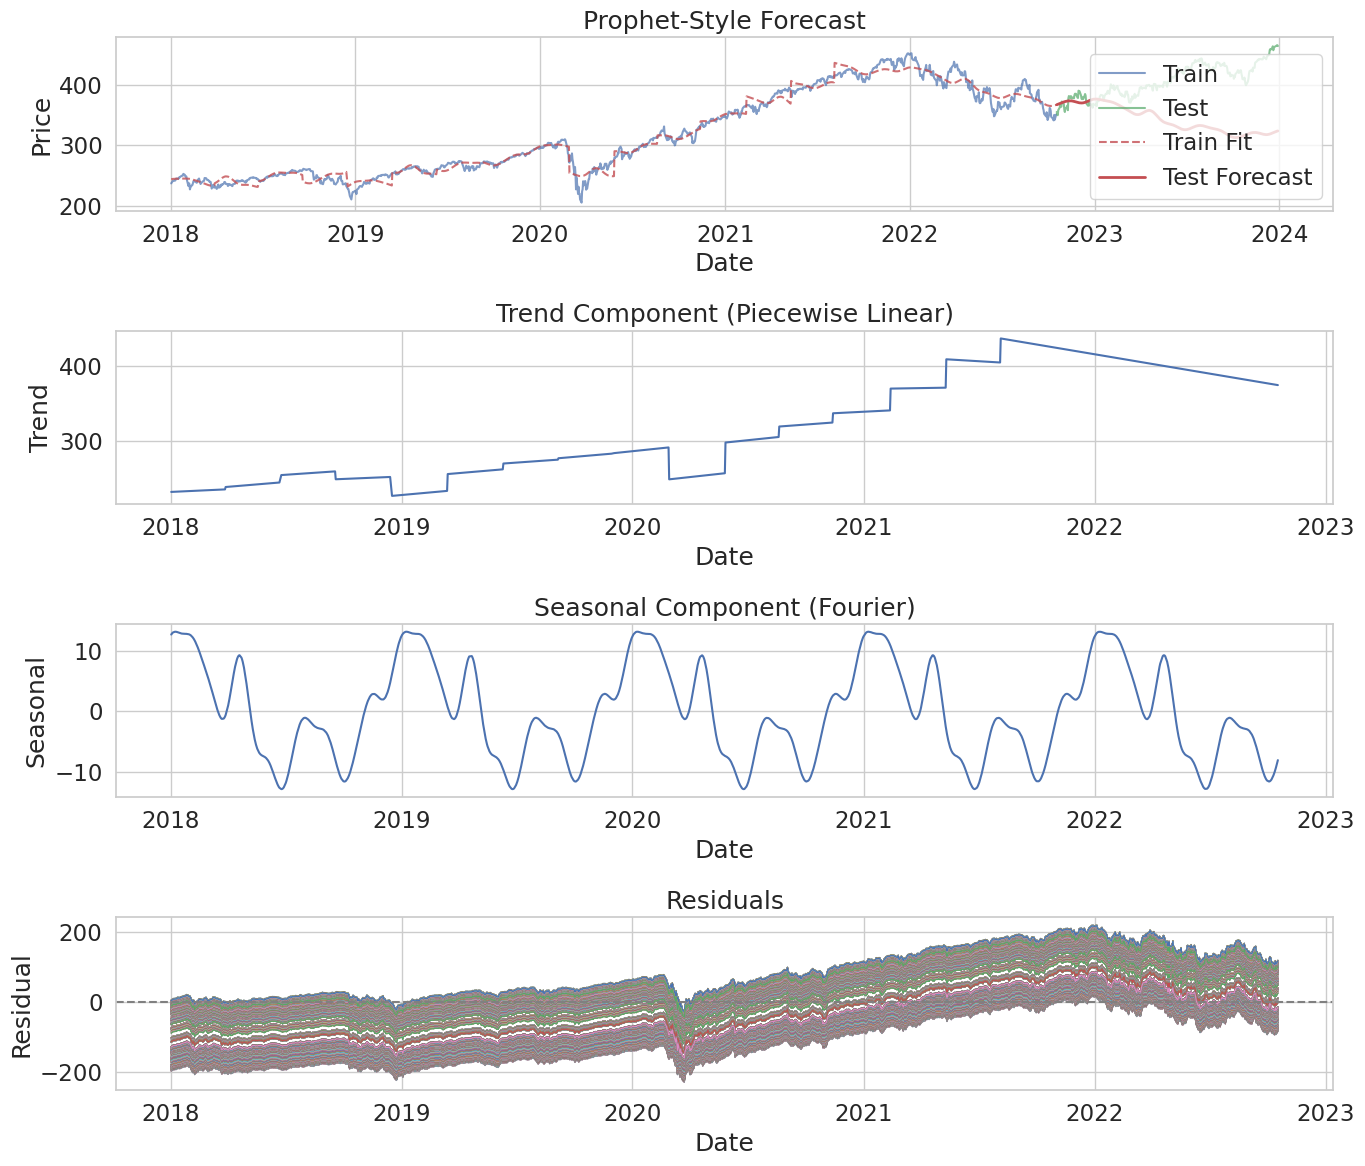


Prophet-style Model Performance:
  Train RMSE: $96.79
  Test RMSE:  $71.69


In [18]:
# Demonstrate Prophet-style model on stock data
spy_daily = spy.copy()

# Split train/test
train_size = int(0.8 * len(spy_daily))
train_dates = spy_daily.index[:train_size]
test_dates = spy_daily.index[train_size:]
y_train = spy_daily.values[:train_size]
y_test = spy_daily.values[train_size:]

# Fit our simple Prophet
model = SimpleProphet(yearly_seasonality=True, n_changepoints=15)
model.fit(train_dates, y_train)

# Get predictions
train_pred = model.predict(train_dates)
test_pred = model.predict(test_dates)

# Get components
components = model.get_components(train_dates, y_train)

# Plot results
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

# Forecast
axes[0].plot(train_dates, y_train, 'b-', label='Train', alpha=0.7)
axes[0].plot(test_dates, y_test, 'g-', label='Test', alpha=0.7)
axes[0].plot(train_dates, train_pred, 'r--', label='Train Fit', alpha=0.8)
axes[0].plot(test_dates, test_pred, 'r-', label='Test Forecast', linewidth=2)
axes[0].set_ylabel('Price')
axes[0].set_title('Prophet-Style Forecast')
axes[0].legend()
axes[0].set_xlabel('Date')

# Trend component
axes[1].plot(train_dates, components['trend'])
axes[1].set_ylabel('Trend')
axes[1].set_title('Trend Component (Piecewise Linear)')
axes[1].set_xlabel('Date')

# Seasonal component
axes[2].plot(train_dates, components['seasonal'])
axes[2].set_ylabel('Seasonal')
axes[2].set_title('Seasonal Component (Fourier)')
axes[2].set_xlabel('Date')

# Residual
axes[3].plot(train_dates, components['residual'], linewidth=0.8)
axes[3].axhline(0, color='gray', linestyle='--')
axes[3].set_ylabel('Residual')
axes[3].set_title('Residuals')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.show()

# Performance metrics
train_rmse = np.sqrt(np.mean((y_train - train_pred)**2))
test_rmse = np.sqrt(np.mean((y_test - test_pred)**2))
print(f"\nProphet-style Model Performance:")
print(f"  Train RMSE: ${train_rmse:.2f}")
print(f"  Test RMSE:  ${test_rmse:.2f}")

## 4.2 N-BEATS (Neural Basis Expansion Analysis)

### Underlying Assumptions

N-BEATS assumes:

1. **Univariate focus** - Designed for single time series (extensions exist for multivariate)

2. **Basis expansion** - Output can be expressed as weighted combination of basis functions
   - Interpretable: Polynomial (trend) + Fourier (seasonal)
   - Generic: Learned bases for maximum flexibility

3. **Residual learning** - Each block explains part of the signal, residual passed to next
   - Inspired by boosting and residual networks
   - Allows specialization of blocks

4. **Sufficient training data** - Deep model needs adequate samples
   - Data augmentation via sliding window helps
   - Pre-training on similar series can help

5. **Stationarity not required** - Network learns to handle trends and seasonality
   - Normalization typically applied per-window

**When to use:**
- Medium to large datasets
- When interpretability via trend/seasonal is valuable
- Univariate forecasting benchmarks
- When you want pure deep learning (no manual feature engineering)

**When NOT to use:**
- Very small datasets (overfitting risk)
- Multivariate with complex cross-series dependencies (use other architectures)
- Real-time with strict latency requirements

### Architecture

Each **block** produces:
- **Backcast**: $\hat{\mathbf{x}} = \sum_{i} \theta_i^b \cdot \mathbf{v}_i^b$ (reconstruction of input)
- **Forecast**: $\hat{\mathbf{y}} = \sum_{i} \theta_i^f \cdot \mathbf{v}_i^f$ (prediction)

### Interpretable Bases

**Trend block**: Polynomial basis
$$\mathbf{v}_i^{trend} = [1, t, t^2, \ldots, t^p]$$

**Seasonality block**: Fourier basis
$$\mathbf{v}_i^{seasonal} = [\cos(2\pi t/P), \sin(2\pi t/P), \ldots]$$

### Generic Block

Uses learned linear projection instead of fixed basis.
$$\hat{\mathbf{y}} = W_{out} \cdot \theta$$
where $W_{out}$ is a learnable matrix.

### Doubly Residual Learning

Stacks connected via residual connections:
1. Backcast residual: $\mathbf{x}_{l+1} = \mathbf{x}_l - \hat{\mathbf{x}}_l$
2. Forecast sum: $\mathbf{y} = \sum_l \hat{\mathbf{y}}_l$

**Why doubly residual?**
- Backcast residual: Each block only needs to model what previous blocks missed
- Forecast sum: Each block contributes to final forecast

### How Parameters Are Fit

**Objective:** Minimize MSE on forecast horizon
$$\mathcal{L} = \frac{1}{H} \sum_{h=1}^{H} (y_{t+h} - \hat{y}_{t+h})^2$$

**Training procedure:**
1. Create sliding window samples (input, target) pairs
2. Normalize inputs (per-window or global)
3. Train with Adam optimizer
4. Use early stopping on validation loss
5. Optionally use gradient clipping for stability

In [19]:
class NBeatsBlock(nn.Module):
    """Single N-BEATS block with proper basis handling."""

    def __init__(self, input_size, forecast_size, theta_size, hidden_size=256,
                 n_layers=4, basis_type='generic'):
        super().__init__()

        self.input_size = input_size
        self.forecast_size = forecast_size
        self.theta_size = theta_size
        self.basis_type = basis_type

        # Fully connected stack
        layers = []
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())
        self.fc_stack = nn.Sequential(*layers)

        # Theta layers for backcast and forecast coefficients
        self.theta_b = nn.Linear(hidden_size, theta_size)
        self.theta_f = nn.Linear(hidden_size, theta_size)

        # For generic basis: use learnable linear projection
        # This fixes the dimension mismatch issue when theta_size != output_size
        if basis_type == 'generic':
            self.backcast_proj = nn.Linear(theta_size, input_size)
            self.forecast_proj = nn.Linear(theta_size, forecast_size)

    def forward(self, x):
        """
        x: (batch, input_size)
        returns: backcast (batch, input_size), forecast (batch, forecast_size)
        """
        # FC stack
        h = self.fc_stack(x)

        # Theta coefficients
        theta_b = self.theta_b(h)  # (batch, theta_size)
        theta_f = self.theta_f(h)  # (batch, theta_size)

        # Generate outputs using basis expansion
        backcast = self._basis_expansion(theta_b, self.input_size, is_backcast=True)
        forecast = self._basis_expansion(theta_f, self.forecast_size, is_backcast=False)

        return backcast, forecast

    def _basis_expansion(self, theta, size, is_backcast):
        """Expand theta coefficients to output size using basis functions."""
        batch_size = theta.shape[0]
        device = theta.device

        # Create normalized time vector
        t = torch.linspace(0, 1, size, device=device)

        if self.basis_type == 'trend':
            # Polynomial basis: [1, t, t^2, ..., t^(theta_size-1)]
            basis = torch.stack([t**i for i in range(self.theta_size)], dim=0)
            # basis: (theta_size, size)
            return torch.matmul(theta, basis)  # (batch, size)

        elif self.basis_type == 'seasonal':
            # Fourier basis: [cos(2πt), sin(2πt), cos(4πt), sin(4πt), ...]
            n_harmonics = self.theta_size // 2
            basis_list = []
            for n in range(1, n_harmonics + 1):
                basis_list.append(torch.cos(2 * np.pi * n * t))
                basis_list.append(torch.sin(2 * np.pi * n * t))
            # Ensure we have exactly theta_size basis functions
            basis = torch.stack(basis_list[:self.theta_size], dim=0)
            return torch.matmul(theta, basis)

        else:  # generic
            # Use learnable linear projection to handle any dimension mismatch
            if is_backcast:
                return self.backcast_proj(theta)
            else:
                return self.forecast_proj(theta)


class NBeats(nn.Module):
    """N-BEATS model with interpretable or generic stacks."""

    def __init__(self, input_size, forecast_size, n_stacks=2,
                 n_blocks_per_stack=3, hidden_size=128, theta_size=8,
                 stack_types=None):
        super().__init__()

        self.input_size = input_size
        self.forecast_size = forecast_size

        # Default stack configuration
        if stack_types is None:
            if n_stacks == 2:
                stack_types = ['trend', 'seasonal']
            else:
                stack_types = ['generic'] * n_stacks

        # Create stacks
        self.stacks = nn.ModuleList()

        for stack_type in stack_types:
            stack = nn.ModuleList()
            for _ in range(n_blocks_per_stack):
                block = NBeatsBlock(
                    input_size=input_size,
                    forecast_size=forecast_size,
                    theta_size=theta_size,
                    hidden_size=hidden_size,
                    basis_type=stack_type
                )
                stack.append(block)
            self.stacks.append(stack)

    def forward(self, x):
        """
        x: (batch, input_size)
        returns: forecast (batch, forecast_size)
        """
        forecast = torch.zeros(x.shape[0], self.forecast_size, device=x.device)

        residual = x
        for stack in self.stacks:
            for block in stack:
                backcast, block_forecast = block(residual)
                residual = residual - backcast  # Residual connection
                forecast = forecast + block_forecast  # Aggregate forecasts

        return forecast

print("N-BEATS model defined successfully.")

N-BEATS model defined successfully.


Data splits: Train=76, Val=16, Test=17

Training N-BEATS...
Epoch 50/300, Train Loss: 0.022308, Val Loss: 0.060460
Early stopping at epoch 88


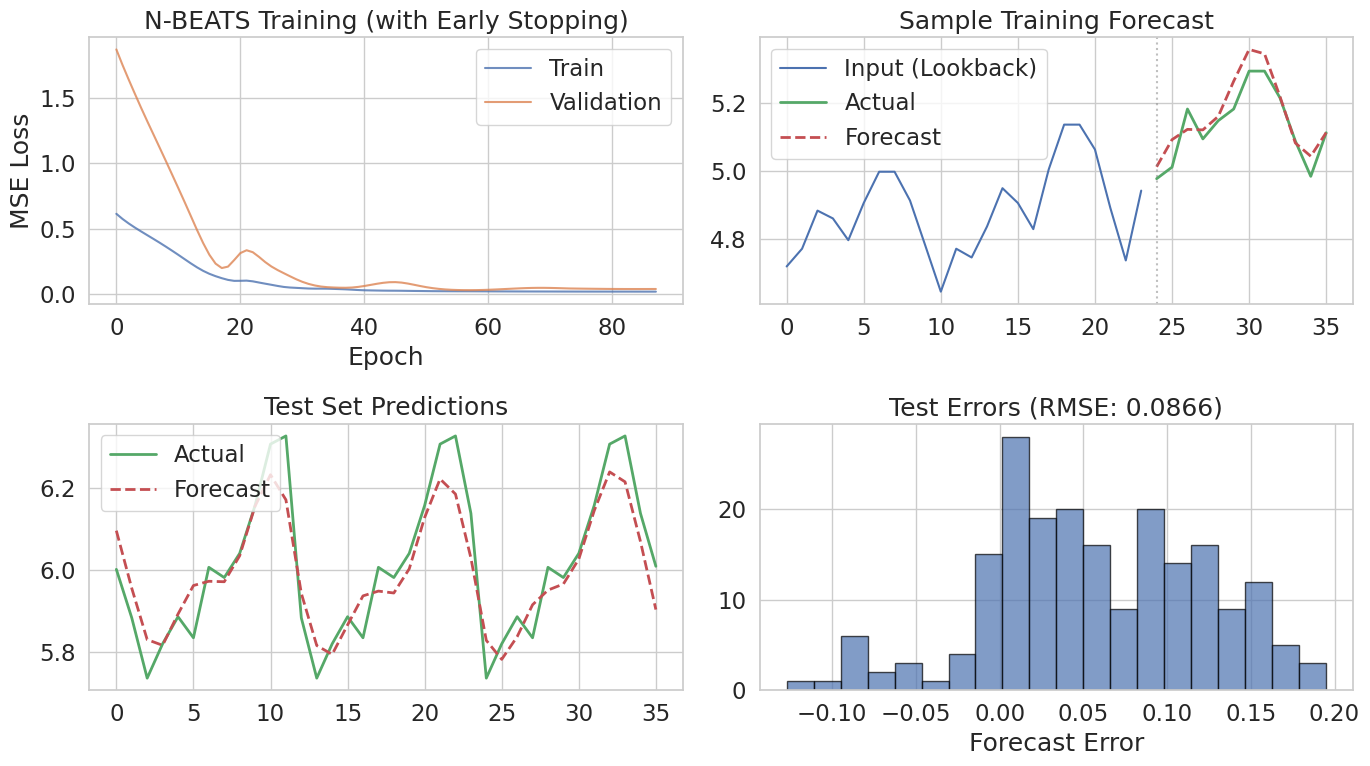


N-BEATS Performance:
  Train RMSE: 0.0511
  Val RMSE:   0.0615
  Test RMSE:  0.0866


In [20]:
def create_sequences(data, input_size, forecast_size):
    """Create input/output sequences for training."""
    X, y = [], []
    for i in range(len(data) - input_size - forecast_size + 1):
        X.append(data[i:i + input_size])
        y.append(data[i + input_size:i + input_size + forecast_size])
    return np.array(X), np.array(y)


def train_nbeats(model, X_train, y_train, X_val, y_val,
                 n_epochs=300, lr=0.001, patience=20, verbose=True):
    """Train N-BEATS with early stopping and gradient clipping.

    Parameters
    ----------
    model : NBeats
        N-BEATS model instance
    X_train, y_train : torch.Tensor
        Training data
    X_val, y_val : torch.Tensor
        Validation data for early stopping
    n_epochs : int
        Maximum training epochs
    lr : float
        Learning rate
    patience : int
        Early stopping patience
    verbose : bool
        Print progress

    Returns
    -------
    losses : dict with 'train' and 'val' loss histories
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=patience//2
    )
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(n_epochs):
        # Training
        model.train()
        optimizer.zero_grad()

        train_pred = model(X_train)
        train_loss = criterion(train_pred, y_train)

        train_loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(train_loss.item())

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)
        val_losses.append(val_loss.item())

        # Learning rate scheduling
        scheduler.step(val_loss)

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break

        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss.item():.6f}, "
                  f"Val Loss: {val_loss.item():.6f}")

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    return {'train': train_losses, 'val': val_losses}


# Prepare data
data = log_passengers.values
input_size = 24  # 2 years of lookback
forecast_size = 12  # 1 year forecast

X_seq, y_seq = create_sequences(data, input_size, forecast_size)

# Normalize
mean, std = X_seq.mean(), X_seq.std()
X_norm = (X_seq - mean) / std
y_norm = (y_seq - mean) / std

# Split: 70% train, 15% val, 15% test
n_samples = len(X_norm)
train_end = int(0.7 * n_samples)
val_end = int(0.85 * n_samples)

X_train = torch.FloatTensor(X_norm[:train_end])
y_train = torch.FloatTensor(y_norm[:train_end])
X_val = torch.FloatTensor(X_norm[train_end:val_end])
y_val = torch.FloatTensor(y_norm[train_end:val_end])
X_test = torch.FloatTensor(X_norm[val_end:])
y_test = torch.FloatTensor(y_norm[val_end:])

print(f"Data splits: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

# Create model
model = NBeats(
    input_size=input_size,
    forecast_size=forecast_size,
    n_stacks=2,
    n_blocks_per_stack=2,
    hidden_size=64,
    theta_size=4,
    stack_types=['trend', 'seasonal']
)

# Train with early stopping
print("\nTraining N-BEATS...")
losses = train_nbeats(
    model, X_train, y_train, X_val, y_val,
    n_epochs=300, lr=0.001, patience=30, verbose=True
)

# Evaluate
model.eval()
with torch.no_grad():
    train_pred = model(X_train).numpy()
    val_pred = model(X_val).numpy()
    test_pred = model(X_test).numpy()

# Denormalize
train_pred = train_pred * std + mean
val_pred = val_pred * std + mean
test_pred = test_pred * std + mean
y_train_actual = y_train.numpy() * std + mean
y_val_actual = y_val.numpy() * std + mean
y_test_actual = y_test.numpy() * std + mean

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Training loss with early stopping
axes[0, 0].plot(losses['train'], label='Train', alpha=0.8)
axes[0, 0].plot(losses['val'], label='Validation', alpha=0.8)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('N-BEATS Training (with Early Stopping)')
axes[0, 0].legend()

# Sample forecast
sample_idx = 0
axes[0, 1].plot(range(input_size), X_train[sample_idx].numpy() * std + mean,
                'b-', label='Input (Lookback)')
axes[0, 1].plot(range(input_size, input_size + forecast_size),
                y_train_actual[sample_idx], 'g-', label='Actual', linewidth=2)
axes[0, 1].plot(range(input_size, input_size + forecast_size),
                train_pred[sample_idx], 'r--', label='Forecast', linewidth=2)
axes[0, 1].axvline(input_size, color='gray', linestyle=':', alpha=0.5)
axes[0, 1].legend()
axes[0, 1].set_title('Sample Training Forecast')

# Test predictions
axes[1, 0].plot(y_test_actual.flatten()[:36], 'g-', label='Actual', linewidth=2)
axes[1, 0].plot(test_pred.flatten()[:36], 'r--', label='Forecast', linewidth=2)
axes[1, 0].legend()
axes[1, 0].set_title('Test Set Predictions')

# Error distribution
test_errors = (y_test_actual - test_pred).flatten()
axes[1, 1].hist(test_errors, bins=20, edgecolor='black', alpha=0.7)
rmse = np.sqrt(np.mean(test_errors**2))
axes[1, 1].set_xlabel('Forecast Error')
axes[1, 1].set_title(f'Test Errors (RMSE: {rmse:.4f})')

plt.tight_layout()
plt.show()

print(f"\nN-BEATS Performance:")
print(f"  Train RMSE: {np.sqrt(np.mean((y_train_actual - train_pred)**2)):.4f}")
print(f"  Val RMSE:   {np.sqrt(np.mean((y_val_actual - val_pred)**2)):.4f}")
print(f"  Test RMSE:  {rmse:.4f}")

## 4.3 PatchTST (Patch Time Series Transformer)

### Underlying Assumptions

PatchTST assumes:

1. **Patch-wise local patterns** - Time series has meaningful local structures
   - Similar to image patches in Vision Transformers
   - Reduces sequence length and computational cost

2. **Long-range dependencies** - Self-attention can capture distant relationships
   - Unlike convolutions or RNNs that have limited receptive fields
   - Important for series with long-term patterns

3. **Channel independence** - Each variate can be processed separately
   - Reduces overfitting on small datasets
   - Enables transfer learning across different series

4. **Positional information matters** - Position embeddings capture temporal ordering
   - Without position embeddings, transformer is permutation-invariant

**When to use:**
- Long sequences where LSTM/RNN struggle
- Series with both local and global patterns
- Transfer learning scenarios
- When computational efficiency over long contexts matters

**When NOT to use:**
- Very short sequences (patching overhead)
- When interpretability is critical (attention is hard to interpret)
- Limited computational resources (still more expensive than simple models)

### Key Innovations

1. **Patch Embedding**: Segment time series into subseries patches
   - Input: $\mathbf{x} \in \mathbb{R}^L$ → Patches: $\mathbf{x}_p \in \mathbb{R}^{N \times P}$
   - $N = \lfloor(L - P)/S\rfloor + 1$ patches, size $P$, stride $S$

2. **Channel Independence**: Each variate processed separately
   - Reduces overfitting on small datasets
   - Enables transfer learning

3. **Self-Attention on Patches**
   - Captures long-range dependencies efficiently
   - Computational complexity: $O(N^2)$ instead of $O(L^2)$

### Architecture

$$\text{Patches} \xrightarrow{\text{Linear}} \text{Embeddings} \xrightarrow{\text{+Pos Embed}} \text{Transformer} \xrightarrow{\text{Flatten}} \text{Linear} \xrightarrow{} \text{Forecast}$$

### How Parameters Are Fit

**Objective:** MSE loss on forecast horizon (same as N-BEATS)

**Training procedure:**
1. Create patches from input windows
2. Add learnable position embeddings
3. Process through transformer encoder layers
4. Flatten output and project to forecast length
5. Train with Adam optimizer and early stopping

In [21]:
class PatchEmbedding(nn.Module):
    """Patch embedding for time series."""

    def __init__(self, patch_size, d_model, seq_len, stride=None):
        super().__init__()
        self.patch_size = patch_size
        self.stride = stride or patch_size
        self.n_patches = (seq_len - patch_size) // self.stride + 1

        # Linear projection of patches
        self.projection = nn.Linear(patch_size, d_model)

        # Learnable position embeddings
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)

    def forward(self, x):
        """
        x: (batch, seq_len)
        returns: (batch, n_patches, d_model)
        """
        # Create patches using unfold
        patches = x.unfold(dimension=1, size=self.patch_size, step=self.stride)
        # patches: (batch, n_patches, patch_size)

        # Project to d_model
        embeddings = self.projection(patches)

        # Add positional embedding
        embeddings = embeddings + self.pos_embed

        return embeddings


class SimplePatchTST(nn.Module):
    """Simplified PatchTST model."""

    def __init__(self, seq_len, pred_len, patch_size=16, d_model=64,
                 n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len

        # Patch embedding
        self.patch_embed = PatchEmbedding(patch_size, d_model, seq_len)
        n_patches = self.patch_embed.n_patches

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Output projection
        self.flatten = nn.Flatten()
        self.output_proj = nn.Linear(n_patches * d_model, pred_len)

    def forward(self, x):
        """
        x: (batch, seq_len)
        returns: (batch, pred_len)
        """
        # Patch embedding with position encoding
        patches = self.patch_embed(x)

        # Transformer encoder
        encoded = self.transformer(patches)

        # Flatten and project to forecast
        flat = self.flatten(encoded)
        output = self.output_proj(flat)

        return output

print("PatchTST model defined successfully.")

PatchTST model defined successfully.


Training PatchTST...
Epoch 50/300, Train Loss: 0.039959, Val Loss: 0.059022
Epoch 100/300, Train Loss: 0.023778, Val Loss: 0.033575
Epoch 150/300, Train Loss: 0.017058, Val Loss: 0.030348
Early stopping at epoch 182


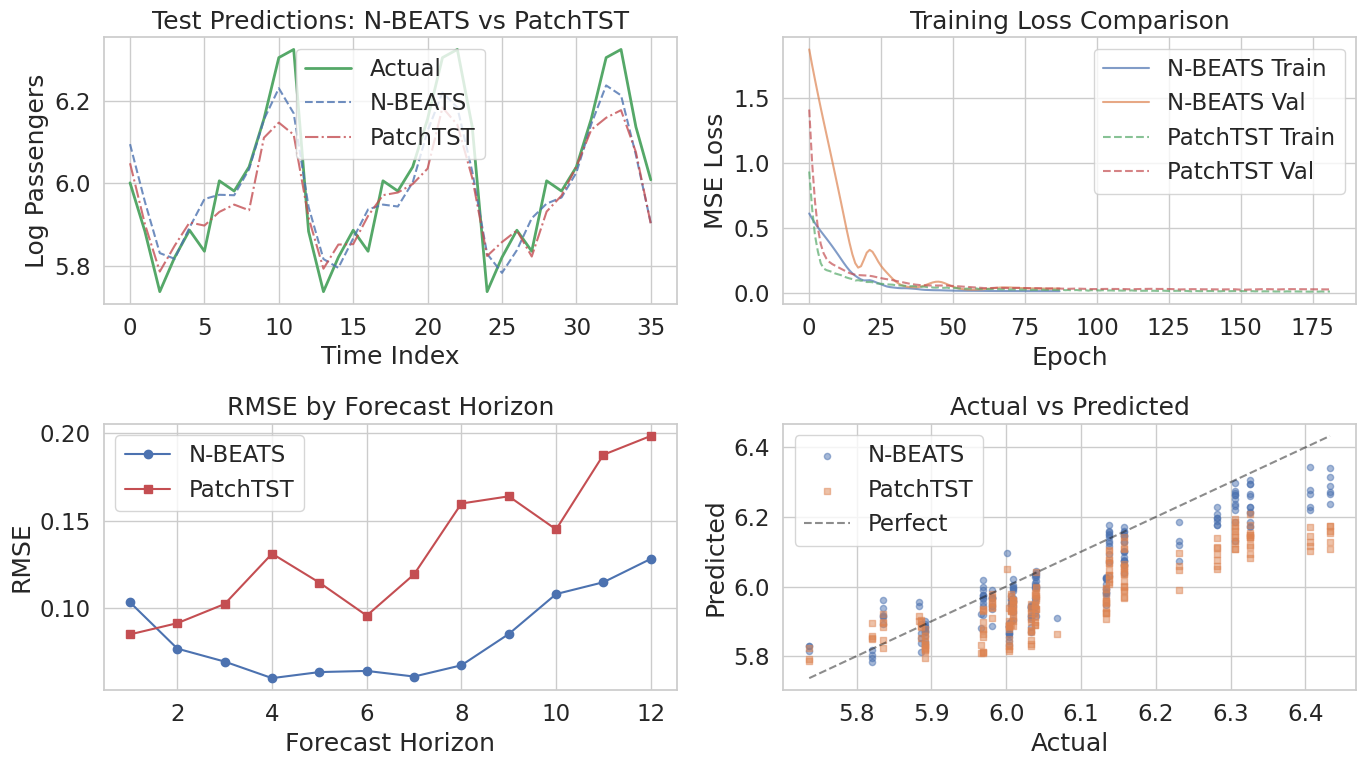


Model Comparison (Test Set):
  N-BEATS RMSE:  0.0866
  PatchTST RMSE: 0.1378
  Winner: N-BEATS


In [22]:
def train_patchtst(model, X_train, y_train, X_val, y_val,
                    n_epochs=300, lr=0.001, patience=20, verbose=True):
    """Train PatchTST with early stopping."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=patience//2
    )
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(n_epochs):
        # Training
        model.train()
        optimizer.zero_grad()

        train_pred = model(X_train)
        train_loss = criterion(train_pred, y_train)

        train_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(train_loss.item())

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)
        val_losses.append(val_loss.item())

        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break

        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss.item():.6f}, "
                  f"Val Loss: {val_loss.item():.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return {'train': train_losses, 'val': val_losses}


# Use same data as N-BEATS
patch_input_size = 24
patch_forecast_size = 12
patch_size = 4  # Each patch covers 4 time steps

# Create PatchTST model
patchtst = SimplePatchTST(
    seq_len=patch_input_size,
    pred_len=patch_forecast_size,
    patch_size=patch_size,
    d_model=32,
    n_heads=4,
    n_layers=2,
    dropout=0.1
)

# Train with early stopping
print("Training PatchTST...")
patch_losses = train_patchtst(
    patchtst, X_train, y_train, X_val, y_val,
    n_epochs=300, lr=0.001, patience=30, verbose=True
)

# Evaluate
patchtst.eval()
with torch.no_grad():
    patch_train_pred = patchtst(X_train).numpy()
    patch_val_pred = patchtst(X_val).numpy()
    patch_test_pred = patchtst(X_test).numpy()

# Denormalize
patch_train_pred = patch_train_pred * std + mean
patch_val_pred = patch_val_pred * std + mean
patch_test_pred = patch_test_pred * std + mean

# Compare N-BEATS vs PatchTST
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Test predictions comparison
axes[0, 0].plot(y_test_actual.flatten()[:36], 'g-', label='Actual', linewidth=2)
axes[0, 0].plot(test_pred.flatten()[:36], 'b--', label='N-BEATS', alpha=0.8)
axes[0, 0].plot(patch_test_pred.flatten()[:36], 'r-.', label='PatchTST', alpha=0.8)
axes[0, 0].legend()
axes[0, 0].set_title('Test Predictions: N-BEATS vs PatchTST')
axes[0, 0].set_xlabel('Time Index')
axes[0, 0].set_ylabel('Log Passengers')

# Training loss comparison
axes[0, 1].plot(losses['train'], label='N-BEATS Train', alpha=0.7)
axes[0, 1].plot(losses['val'], label='N-BEATS Val', alpha=0.7)
axes[0, 1].plot(patch_losses['train'], label='PatchTST Train', alpha=0.7, linestyle='--')
axes[0, 1].plot(patch_losses['val'], label='PatchTST Val', alpha=0.7, linestyle='--')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE Loss')
axes[0, 1].set_title('Training Loss Comparison')
axes[0, 1].legend()

# Per-horizon error comparison
nbeats_horizon_rmse = np.sqrt(np.mean((y_test_actual - test_pred)**2, axis=0))
patchtst_horizon_rmse = np.sqrt(np.mean((y_test_actual - patch_test_pred)**2, axis=0))
horizons = np.arange(1, forecast_size + 1)

axes[1, 0].plot(horizons, nbeats_horizon_rmse, 'b-o', label='N-BEATS')
axes[1, 0].plot(horizons, patchtst_horizon_rmse, 'r-s', label='PatchTST')
axes[1, 0].set_xlabel('Forecast Horizon')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].set_title('RMSE by Forecast Horizon')
axes[1, 0].legend()

# Scatter plot: Actual vs Predicted
axes[1, 1].scatter(y_test_actual.flatten(), test_pred.flatten(),
                   alpha=0.5, label='N-BEATS', s=20)
axes[1, 1].scatter(y_test_actual.flatten(), patch_test_pred.flatten(),
                   alpha=0.5, label='PatchTST', s=20, marker='s')
lims = [y_test_actual.min(), y_test_actual.max()]
axes[1, 1].plot(lims, lims, 'k--', alpha=0.5, label='Perfect')
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')
axes[1, 1].set_title('Actual vs Predicted')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# RMSE comparison
nbeats_rmse = np.sqrt(np.mean((y_test_actual - test_pred)**2))
patchtst_rmse = np.sqrt(np.mean((y_test_actual - patch_test_pred)**2))

print(f"\nModel Comparison (Test Set):")
print(f"  N-BEATS RMSE:  {nbeats_rmse:.4f}")
print(f"  PatchTST RMSE: {patchtst_rmse:.4f}")
print(f"  Winner: {'N-BEATS' if nbeats_rmse < patchtst_rmse else 'PatchTST'}")